# 2026-10-04 Numerical predictions of the simple gas-fading and BPT model

This notebook follows the simplified report
[20261003 The Origin of Fading Emission Lines and Increasing BPT Line Ratios along Infall Stages](../MAUVE/20261003%20The%20Origin%20of%20Fading%20Emission%20Lines%20and%20Increasing%20BPT%20Line%20Ratios%20along%20Infall%20Stages.md).
That report supplies the model equations. The current experiment uses the user-selected
feedback loading $\eta=3$ and an explicit illustrative 30% HOLMES Composite starting state.
We evaluate the constant-coefficient,
HI-only stripping model, its atomic leading/reference/trailing perturbation, and its
two-component **young (compact HII + leaked OB) + HOLMES** line budget. All figures use
`plt.show()` and are embedded in the notebook; no figure files are written.

## Adopted values and assumptions

| Quantity | Value or rule used here | Status and meaning |
| --- | --- | --- |
| Molecular depletion time $\tau_{\rm dep}$ | 2 Gyr | Assumed constant; total SFR, before recycling |
| Prompt mass return $R$ | 0.4 | Assumed constant |
| Feedback loading $\eta$ | 3 | User-selected assumed outflow loading; molecular outflow rate $\eta\Sigma_{\rm SFR}$ |
| HI stripping coefficient $\gamma_{\rm strip}$ | 3 Gyr$^{-1}$ | Assumed; no direct H$_2$ stripping |
| Reference initial HI column $\Sigma_{{\rm HI},0}$ | 10 $M_\odot\,\mathrm{pc}^{-2}$ | Illustrative local atomic column; not measured from these optical maps |
| Atomic factors $c_{\rm HI}$ | trailing 0.5; reference 1; leading 1.5 | Assumed initial conditions; common initial H$_2$ and common coefficients |
| Temporal initial-condition examples | Initial H$_2$ = 2.0 or 0.4 times the data-normalized baseline; initial HI and all coefficients fixed; no spatial perturbation | Assumed illustrative starting columns. These select declining or initially rising **reference histories**, independently of the leading/trailing comparison |
| Model H$\alpha$ calibration $C_\alpha$ | $4.98\times10^{-42}$ $M_\odot\,\mathrm{yr}^{-1}/(\mathrm{erg\,s}^{-1})$ | Report equation (31), Chabrier IMF; actual data conversion uses each FITS header's `SFRCOEF` |
| HOLMES ionizing yield $q_{\rm H,HOLMES}$ | $7\times10^{40}$ s$^{-1}M_\odot^{-1}$ | Report equation (32), adopted from Belfiore et al. (2022) |
| H$\alpha$ energy yield $\epsilon_\alpha$ | $1.3721\times10^{-12}$ erg per absorbed ionizing photon | Report equation (33), Case B |
| Old stellar fraction $f_{\rm old}$ | 1 | Explicit upper-normalization assumption: $\Sigma_*^{\rm old}=f_{\rm old}\Sigma_*$; total mass is measured, age-separated old mass is not |
| Absorbed HOLMES photon fraction | 1 | Implicit full-absorption assumption of the simple report; absorbing gas and old mass remain |
| Both intrinsic Balmer decrements | H$\alpha$/H$\beta$ = 2.86 | Common H$\alpha$ and H$\beta$ mixing weight, report equation (37) |
| HOLMES intrinsic log10 ratios | N2 = +0.25; S2 = +0.20; O3 = +0.5 | User-selected illustrative templates; linear values are $10^{0.25}$, $10^{0.20}$, $10^{0.5}$ |
| Reference stellar column and observed comparison H$\alpha$ | Live pre-peak NSF medians | Distinct from the illustrative model total H$\alpha$ |
| Initial HOLMES Balmer fraction $w_0$ | 0.30 | Assumed faint-NSF initial state; N2 BPT coordinates checked between Ka03 and Ke01 |
| Model initial total H$\alpha$ | Adopted stellar-mass HOLMES luminosity divided by $w_0$ | Printed alongside observed NSF median; not forced to match it |
| Initial H$_2$ column | $\Sigma_{{\rm H_2},0}=\tau_{\rm dep}\Sigma_{{\rm SFR},0}$, using the young luminosity implied by $w_0=0.30$ | Model-derived from the illustrative starting state; not a CO measurement |
| Conversion time $\tau_{\rm conv}$ | $\Sigma_{{\rm HI},0}/(\gamma_{\rm H_2}\Sigma_{{\rm H_2},0})$ | Derived by requiring initial supply-consumption balance in the reference position |
| Young intrinsic log10 ratios | N2 = -1.0; S2 = -1.2; O3 = -0.5 | User-selected illustrative templates; linear values are $10^{-1.0}$, $10^{-1.2}$, $10^{-0.5}$ |
| Time grid | 0--2 Gyr, 1001 samples; checkpoints at 0.5, 1.0, 1.5, and 2.0 Gyr | Illustrative elapsed time since imposed conditions; **no times assigned to observed infall stages** |

N2 = [N II]6583/H$\alpha$; S2 = ([S II]6716 + [S II]6731)/H$\alpha$;
O3 = [O III]5007/H$\beta$. Mixing is performed in **linear** ratios and luminosities.
The assumed ordering of the intrinsic ratios is part of this simple model.

For the observational scale we use one fixed stellar-density interval,
$8.5\leq\log_{10}(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])<8.75$.
We use the existing project's inclination cut $i<80^\circ$, retained stellar-fit
`SNR_POSTFIT > 25`, and six-line common detection support. SF requires finite HII SFR,
EW(H$\alpha$) $>6$ Angstrom, and intrinsic H$\alpha$ dispersion $<45$ km s$^{-1}$.
NSF is Balmer-detected usable emission outside SF; it is **not a HOLMES-only label**.
At least 50 usable pixels and 20 common six-line pixels per product/category are required.
Pre-peak NSF provides the old-stellar normalization and comparison scale. Both component
spectra are explicit assumed templates, not extracted from the SF or NSF medians.
The data points below are descriptive comparisons within this mass interval, not a fit
of an evolutionary track to the stages.
Plotting notes: each line plot prints its first plotted value and, for model curves, the initial gas columns and rates with units. Positive gas-column, supply/consumption-rate and SFR histories use logarithmic y-axes. Signed dex offsets and early-time insets retain linear axes to resolve the small rise. BPT boundaries and observed diagnostics have no assigned gas initial conditions.

All observational central-value summaries use medians. Bars on observed stage points and NSF diagnostic fractions show product-to-product 16th--84th percentile scatter of the same quantity. Physical luminosity sums and young/HOLMES mixing weights retain their definitions.


In [1]:
from pathlib import Path
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display, Markdown

PROJECT_ROOT = Path('/Users/Igniz/Desktop/ICRAR/further')
DATA_ROOT = PROJECT_ROOT / 'v3tk_v7.6.8'
CATALOG_PATH = PROJECT_ROOT / 'mauve_master_wiki_newclass.fits'
GEOMETRY_PATH = PROJECT_ROOT / 'MAUVE_effective_radii.csv'
REPORT_PATH = PROJECT_ROOT.parent / 'MAUVE' / (
    '20261003 The Origin of Fading Emission Lines and Increasing BPT Line Ratios along Infall Stages.md')
MASK_SOURCE = PROJECT_ROOT / '20260930_check_emission_line_fading_BPT_ratios_Halpha_sigma_SF_NSF_by_stage.ipynb'
PIPELINE_PATH = PROJECT_ROOT / 'SFR+Z.py'
MASS_RANGE = (8.5, 8.75)
MIN_USABLE = 50
MIN_COMMON = 20
SNR_MIN = 25.0
EW_MIN = 6.0
SIGMA_MAX = 45.0
INCLINATION_MAX = 80.0
WCS_TOLERANCE = 0.05  # arcsec at corners and centre
TAU_DEP = 2.0        # Gyr
RETURN_FRACTION = 0.4
ETA = 3.0          # assumed feedback mass loading; outflow = eta * SFR
GAMMA_STRIP = 3.0    # Gyr^-1; HI only
SIGMA_HI_0 = 10.0    # Msun pc^-2
C_ALPHA = 4.98e-42
Q_H_HOLMES = 7.0e40
EPSILON_ALPHA = 1.3721e-12
F_OLD = 1.0
INITIAL_HOLMES_FRACTION = 0.30  # illustrative faint-NSF initial state, not a measured fraction
BALMER_DECREMENT = 2.86
# User-selected log10(line/Balmer) coordinates; exponentiate before luminosity mixing.
YOUNG_LOG_RATIOS = {'N2': -1.0, 'S2': -1.2, 'O3': -0.5}
HOLMES_LOG_RATIOS = {'N2': 0.25, 'S2': 0.20, 'O3': 0.5}
YOUNG_RATIOS = {name: 10.0**value for name,value in YOUNG_LOG_RATIOS.items()}
HOLMES_RATIOS = {name: 10.0**value for name,value in HOLMES_LOG_RATIOS.items()}
ATOMIC_FACTORS = {'trailing': 0.5, 'reference': 1.0, 'leading': 1.5}
TIME_GYR = np.linspace(0.0, 2.0, 1001)
CHECKPOINT_TIMES = np.array([0.5, 1.0, 1.5, 2.0])
CHECKPOINT_MARKERS = ('o', 's', '^', 'D')
STAGES = ('pre-peak', 'close-to-peak', 'post-peak')
STAGE_COLORS = {'pre-peak': '#2166ac', 'close-to-peak': '#1a9850', 'post-peak': '#d73027'}
MODEL_COLORS = {'trailing': '#2166ac', 'reference': '#111111', 'leading': '#e69f00'}
LINE_COLORS = {'Halpha': '#111111', 'Hbeta': '#777777', 'NII': '#b2182b', 'SII': '#1b7837', 'OIII': '#762a83'}
LINES = ('HA6562', 'HB4861', 'NII6583', 'SII6716', 'SII6730', 'OIII5006')
mpl.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.grid': False})
INPUT_PROVENANCE = []

def mark_time_checkpoints(ax, values, color):
    """Dots identify the four common time samples on an elapsed-time curve."""
    return ax.scatter(CHECKPOINT_TIMES, np.interp(CHECKPOINT_TIMES, TIME_GYR, values),
                      color=color, s=23, zorder=4)

def format_time_axis(ax):
    ax.set_xlim(0.0, 2.0)
    ax.set_xticks(np.r_[0.0, CHECKPOINT_TIMES])


def fingerprint(path, hdus=''):
    path = Path(path)
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b''):
            digest.update(block)
    INPUT_PROVENANCE.append({'path': str(path), 'bytes': path.stat().st_size,
                             'sha256': digest.hexdigest(), 'HDUs': hdus})

for path in (REPORT_PATH, CATALOG_PATH, GEOMETRY_PATH, MASK_SOURCE, PIPELINE_PATH):
    fingerprint(path)
print('Model source:', REPORT_PATH)
print('Live product root:', DATA_ROOT)
print('Python:', platform.python_version(), '| NumPy:', np.__version__, '| Matplotlib:', mpl.__version__)

Model source: /Users/Igniz/Desktop/ICRAR/MAUVE/20261003 The Origin of Fading Emission Lines and Increasing BPT Line Ratios along Infall Stages.md
Live product root: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Python: 3.13.3 | NumPy: 2.2.6 | Matplotlib: 3.10.3


## Read the actual MAUVE products

The loader below implements the relevant selection and geometry from the September 30
emission-line notebook (zero-based cells 2, 4, 6, 8, and 10), without executing that
notebook or reading any of its stored outputs. The master FITS catalogue and geometry
CSV supply stage membership and combined-product routing. `NGC4567_8` remains one product
and contributes one weight. Products failing the explicitly displayed checks are excluded.

All six raw lines must meet the product header's `CUT_SN` and `NOISE` detection thresholds;
the ratios then use **corrected** fluxes on that common support. The luminosity per adopted
area is recovered from the actual all-emission H$\alpha$-equivalent SFR map:

$$\mathcal L_\alpha^{\rm observed}
=10^{\mathrm{LOGSFR\_SURFACE\_DENSITY}}/\mathrm{SFRCOEF},\qquad
\mathcal L_\ell^{\rm observed}
=\mathcal L_\alpha^{\rm observed}F_{\ell,\rm corr}/F_{\alpha,\rm corr}.$$

For NSF, that map is a luminosity conversion, not a claim that the emission is powered
by star formation. The existing inclination corrections are already in the surface-density
maps; we apply no additional correction. Stellar and line medians use exactly the same pixels.
Within each product/category we take median linear surface luminosities and median corrected
pixel ratios separately. Within each stage/category we take the median of each product summary.
N2/S2/O3 are medians of pixel ratios followed by medians across products; they are not ratios
of median line luminosities. Every eligible product contributes once. Bars span the 16th--84th
percentiles of the same product summaries in the plotted coordinate and describe galaxy scatter.
Because these are separate medians, the summary line luminosities and ratios need not form one
additive spectrum. The observed medians remain comparison quantities. The model now uses the
NSF median stellar column and a separately stated faint-NSF initial fraction; its young
template is now an explicit user-selected spectrum and physical mixing still uses linear luminosities.

For the NSF audit we additionally read the actual `NII_BPT` and `SII_BPT` class maps,
EW, intrinsic dispersion, and HII-SFR availability on **the same six-line support**.
The original category masks remain unchanged; stage summaries use medians. The first failed
SF gate is bookkeeping, not a unique physical explanation for a region's emission.


In [2]:
def central_hii_masks(n2, s2, o3):
    """Central corrected-ratio cuts, matching SFR+Z.py apply_bpt_masks."""
    x_n2, x_s2, y = np.log10(n2), np.log10(s2), np.log10(o3)
    with np.errstate(divide='ignore', invalid='ignore'):
        n2_hii = (x_n2 < 0.05) & (y < 0.61/(x_n2-0.05)+1.30)
        n2_hii &= y < 0.61/(x_n2-0.47)+1.19
        s2_hii = (x_s2 < 0.32) & (y < 0.72/(x_s2-0.32)+1.30)
    return n2_hii, s2_hii

NSF_GATE_LABELS = (
    'HII SFR unavailable; stable non-HII in at least one BPT plane',
    'HII SFR unavailable; no stable non-HII and not both stable HII',
    'HII SFR unavailable despite both stable HII',
    'HII SFR available; EW missing',
    'HII SFR available; EW <= 6 Angstrom',
    'HII SFR and EW pass; intrinsic dispersion missing',
    'HII SFR and EW pass; intrinsic dispersion >= 45 km/s',
)
NSF_CENTRAL_LABELS = ('central N2 HII-like', 'central S2 HII-like',
                      'central HII-like in both planes', 'stored stable HII in both planes')

def normalise_stage(value):
    return {1: 'pre-peak', 2: 'close-to-peak', 3: 'post-peak'}[int(value)]

def first_product(folder, names):
    for name in names:
        for path in (folder / name, folder / (name + '.gz')):
            if path.is_file():
                return path
    raise FileNotFoundError(f'{folder}: none of {names}')

def read_map(path, name):
    with fits.open(path, memmap=True) as hdul:
        return np.asarray(hdul[name].data, dtype=float).copy(), hdul[name].header.copy()

def require_shape(shape, arrays):
    for name, array in arrays.items():
        if array.shape != shape:
            raise ValueError(f'{name}: {array.shape} differs from {shape}; no silent trimming')

def wcs_separation(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        raise ValueError('Missing celestial WCS')
    ny, nx = shape
    x = np.array([0, nx-1, 0, nx-1, (nx-1)/2])
    y = np.array([0, 0, ny-1, ny-1, (ny-1)/2])
    ra, dec = wa.pixel_to_world_values(x, y)
    rb, db = wb.pixel_to_world_values(x, y)
    return float(np.max(np.hypot((ra-rb)*np.cos(np.deg2rad((dec+db)/2)), dec-db))*3600)

def radius_from_geometry(shape, header, components):
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = WCS(header).celestial.pixel_to_world_values(xx, yy)
    ra, dec = np.deg2rad(ra), np.deg2rad(dec)
    radius = np.full(shape, np.inf)
    for row in components.itertuples(index=False):
        ra0, dec0 = np.deg2rad(row.center_ra_deg), np.deg2rad(row.center_dec_deg)
        dra = (ra-ra0+np.pi) % (2*np.pi)-np.pi
        cosc = np.sin(dec0)*np.sin(dec)+np.cos(dec0)*np.cos(dec)*np.cos(dra)
        east = np.cos(dec)*np.sin(dra)/cosc * 206264.806247
        north = (np.cos(dec0)*np.sin(dec)-np.sin(dec0)*np.cos(dec)*np.cos(dra))/cosc * 206264.806247
        pa = np.deg2rad(row.pa_deg_east_of_north)
        major = east*np.sin(pa)+north*np.cos(pa)
        minor = east*np.cos(pa)-north*np.sin(pa)
        radius = np.minimum(radius, np.hypot(major/row.a_re_arcsec, minor/row.b_re_arcsec))
    return radius

def measure_product(galid, stage, components):
    folder = DATA_ROOT / galid
    paths = {
        'mass': first_product(folder, [f'{galid}_spatial_binning_maps_further.fits']),
        'gas': first_product(folder, [f'{galid}_gas_bin_maps_further.fits', f'{galid}_gas_BIN_maps_further.fits']),
        'ew': first_product(folder, [f'{galid}_proxy_EW_maps_further.fits', f'{galid}_proxy_EW_maps.fits']),
        'mask': first_product(folder, [f'{galid}_mask.fits']),
        'sfh': first_product(folder, [f'{galid}_sfh_maps.fits']),
    }
    mass, mass_header = read_map(paths['mass'], 'LOGMASS_SURFACE_DENSITY')
    if mass_header.get('BUNIT') != 'log(Msol/kpc2)':
        raise ValueError('Unexpected stellar surface-density units')
    shape = mass.shape
    ew, ew_header = read_map(paths['ew'], 'PROXY_EWHA')
    snr, sfh_header = read_map(paths['sfh'], 'SNR_POSTFIT')
    with fits.open(paths['mask'], memmap=True) as hdul:
        flat_mask = np.asarray(hdul['MASKFILE'].data['MASK'], dtype=int).copy()
    if flat_mask.size != mass.size:
        raise ValueError('nGIST mask size mismatch')
    mask = flat_mask.reshape(shape)
    with fits.open(paths['gas'], memmap=True) as hdul:
        header = hdul[0].header.copy()
        gas_header = hdul['BIN_ID'].header.copy()
        names = ('BIN_ID', 'LOGSFR_SURFACE_DENSITY', 'LOGSFR_SURFACE_DENSITY_HII',
                 'HA6562_SIGMA', 'HA6562_SIGMA_CORR', 'NII_BPT', 'SII_BPT')
        arrays = {name: np.asarray(hdul[name].data, dtype=float).copy() for name in names}
        raw = {line: np.asarray(hdul[line+'_FLUX'].data, dtype=float).copy() for line in LINES}
        errors = {line: np.asarray(hdul[line+'_FLUX_ERR'].data, dtype=float).copy() for line in LINES}
        corrected = {line: np.asarray(hdul[line+'_FLUX_CORR'].data, dtype=float).copy() for line in LINES}
    require_shape(shape, {**arrays, 'EW': ew, 'SNR_POSTFIT': snr, **raw,
                          **{k+'_err': v for k,v in errors.items()}, **{k+'_corr': v for k,v in corrected.items()}})
    for other in (gas_header, ew_header, sfh_header):
        if wcs_separation(mass_header, other, shape) > WCS_TOLERANCE:
            raise ValueError('Map WCS mismatch')
    if str(header['BPTMODE']).strip().lower() != 'both':
        raise ValueError('Expected both-BPT HII selection')
    if str(header['DUSTLAW']).strip().lower() != 'calzetti':
        raise ValueError('Expected existing Calzetti correction')
    cut_sn, noise, sfrcoef = [float(header[key]) for key in ('CUT_SN', 'NOISE', 'SFRCOEF')]
    if not all(np.isfinite(v) and v > 0 for v in (cut_sn, noise, sfrcoef)):
        raise ValueError('Invalid detection/calibration header values')
    radius = radius_from_geometry(shape, mass_header, components)
    valid = np.isfinite(mass) & np.isfinite(arrays['BIN_ID']) & (mask == 0) & np.isfinite(radius)
    keep = valid & np.isfinite(snr) & (snr > SNR_MIN)
    sigma2 = arrays['HA6562_SIGMA']**2-arrays['HA6562_SIGMA_CORR']**2
    sigma_intr = np.sqrt(np.where(np.isfinite(sigma2) & (sigma2 > 0), sigma2, np.nan))
    sf = valid & np.isfinite(arrays['LOGSFR_SURFACE_DENSITY_HII']) & np.isfinite(ew) & (ew > EW_MIN)
    sf &= np.isfinite(sigma_intr) & (sigma_intr < SIGMA_MAX)
    detected = {}
    with np.errstate(divide='ignore', invalid='ignore'):
        for line in LINES:
            detected[line] = (np.isfinite(raw[line]) & np.isfinite(errors[line]) & (errors[line] > 0)
                              & (raw[line]/errors[line] >= cut_sn) & (raw[line] >= noise))
    balmer = detected['HA6562'] & detected['HB4861']
    if np.any(sf & ~balmer):
        raise ValueError('Existing SF mask includes a Balmer non-detection')
    nsf, nd = valid & balmer & ~sf, valid & ~balmer
    assert np.array_equal(sf.astype(int)+nsf.astype(int)+nd.astype(int), valid.astype(int))
    common = np.logical_and.reduce(list(detected.values()))
    common &= np.logical_and.reduce([np.isfinite(v) & (v > 0) for v in corrected.values()])
    common &= np.isfinite(arrays['LOGSFR_SURFACE_DENSITY'])
    window = (mass >= MASS_RANGE[0]) & (mass < MASS_RANGE[1])
    n_usable = int((keep & window).sum())
    records, diagnostics = [], []
    for category, category_mask in [('SF', sf), ('NSF', nsf)]:
        use = keep & window & category_mask & common
        n_common = int(use.sum())
        record = {'GALID': galid, 'stage': stage, 'category': category,
                  'N_usable': n_usable, 'N_common': n_common,
                  'eligible': n_usable >= MIN_USABLE and n_common >= MIN_COMMON}
        if n_common:
            lha = np.power(10.0, arrays['LOGSFR_SURFACE_DENSITY'][use])/sfrcoef
            ha_flux = corrected['HA6562'][use]
            line = {k: lha*corrected[k][use]/ha_flux for k in LINES}
            record.update(sigma_star=float(np.median(10.0**mass[use])),
                          Halpha=float(np.median(lha)), Hbeta=float(np.median(line['HB4861'])),
                          NII=float(np.median(line['NII6583'])), OIII=float(np.median(line['OIII5006'])),
                          SII=float(np.median(line['SII6716']+line['SII6730'])),
                          N2=float(np.median(corrected['NII6583'][use]/ha_flux)),
                          S2=float(np.median((corrected['SII6716'][use]+corrected['SII6730'][use])/ha_flux)),
                          O3=float(np.median(corrected['OIII5006'][use]/corrected['HB4861'][use])))
        records.append(record)
        if category == 'NSF' and n_common:
            nii_class, sii_class = arrays['NII_BPT'][use], arrays['SII_BPT'][use]
            if not (np.isin(nii_class, [-1, 0, 1, 2, 3]).all()
                    and np.isin(sii_class, [-1, 0, 1, 2, 3]).all()):
                raise ValueError('Unexpected BPT class codes')
            available = np.isfinite(arrays['LOGSFR_SURFACE_DENSITY_HII'][use])
            stable_non_hii = np.isin(nii_class, [2, 3]) | np.isin(sii_class, [2, 3])
            stable_both_hii = (nii_class == 1) & (sii_class == 1)
            local_ew, local_sigma = ew[use], sigma_intr[use]
            conditions = (~available & stable_non_hii,
                          ~available & ~stable_both_hii,
                          ~available,
                          ~np.isfinite(local_ew), local_ew <= EW_MIN,
                          ~np.isfinite(local_sigma), local_sigma >= SIGMA_MAX)
            remainder = np.ones(n_common, dtype=bool)
            gate_masks = {}
            for label, condition in zip(NSF_GATE_LABELS, conditions):
                gate_masks[label] = remainder & condition
                remainder &= ~condition
            if remainder.any():
                raise ValueError('Unexplained NSF pixels after first-failed-gate decomposition')
            assert np.all(np.sum(list(gate_masks.values()), axis=0) == 1)
            n2_hii, s2_hii = central_hii_masks(
                corrected['NII6583'][use]/ha_flux,
                (corrected['SII6716'][use]+corrected['SII6730'][use])/ha_flux,
                corrected['OIII5006'][use]/corrected['HB4861'][use])
            central_masks = dict(zip(NSF_CENTRAL_LABELS,
                                     (n2_hii, s2_hii, n2_hii & s2_hii, stable_both_hii)))
            for kind, selections in [('first failed SF gate', gate_masks),
                                      ('BPT location/class', central_masks)]:
                for label, selection in selections.items():
                    diagnostics.append({
                        'GALID': galid, 'stage': stage, 'eligible': record['eligible'],
                        'kind': kind, 'selection': label, 'N_NSF_common': n_common,
                        'N_selected': int(selection.sum()), 'pixel_fraction': float(np.count_nonzero(selection)/n_common),
                        # A physical light share is a ratio of summed luminosities, not a central-value estimator.
                        'Halpha_fraction': float(lha[selection].sum()/lha.sum())})
    # Fingerprints are computed from the files actually opened, not cached summaries.
    hdu_lists = {'mass': 'LOGMASS_SURFACE_DENSITY', 'gas': ', '.join(names)+', six raw/error/corrected lines',
                 'ew': 'PROXY_EWHA', 'mask': 'MASKFILE.MASK', 'sfh': 'SNR_POSTFIT'}
    for key, path in paths.items():
        fingerprint(path, hdu_lists[key])
    provenance = {'GALID': galid, **{key: header.get(key) for key in
                  ('CUT_SN', 'NOISE', 'SFRCOEF', 'DIST_MPC', 'SFRIMF', 'DUSTLAW', 'BPTMODE')}}
    return records, provenance, diagnostics

In [3]:
with fits.open(CATALOG_PATH, memmap=True) as hdul:
    master = pd.DataFrame({'galaxy': [str(s).strip() for s in hdul[1].data['Galaxy']],
                           'stage': [normalise_stage(v) for v in hdul[1].data['class']]})
geometry = pd.read_csv(GEOMETRY_PATH).merge(master, on='galaxy', how='left', validate='one_to_one')
if not geometry['stage'].eq(geometry.mauve_infall_stage.map(normalise_stage)).all():
    raise ValueError('Master/geometry stage disagreement')
qc, measured, header_rows, diagnostic_rows = [], [], [], []
for galid, components in geometry.groupby('notebook_product_id', sort=True):
    if components.stage.nunique() != 1:
        raise ValueError(f'{galid}: inconsistent component stages')
    stage, inclination = components.stage.iloc[0], float(components.inclination_deg.max())
    status = 'excluded: inclination >= 80 deg'
    if inclination < INCLINATION_MAX:
        try:
            rows, provenance, diagnostics = measure_product(galid, stage, components)
            measured.extend(rows)
            diagnostic_rows.extend(diagnostics)
            header_rows.append(provenance)
            status = 'OK'
        except (FileNotFoundError, KeyError, ValueError, OSError) as exc:
            status = f'excluded: {type(exc).__name__}: {exc}'
    qc.append({'GALID': galid, 'stage': stage, 'inclination_deg': inclination, 'status': status})
    print(f'{galid}: {status}', flush=True)

SAMPLE_QC = pd.DataFrame(qc)
OBS_BY_GALAXY = pd.DataFrame(measured)
HEADER_PROVENANCE = pd.DataFrame(header_rows)
support_rows = []
for stage in STAGES:
    for category in ('SF', 'NSF'):
        group = OBS_BY_GALAXY.loc[(OBS_BY_GALAXY.stage == stage) &
                                  (OBS_BY_GALAXY.category == category) & OBS_BY_GALAXY.eligible]
        if len(group) < 3:
            raise RuntimeError(f'{stage} {category}: fewer than three supported products; inspect QC/window')
        row = {'stage': stage, 'category': category, 'N_galaxies': len(group),
               'GALIDs': ', '.join(group.GALID)}
        for key in ('sigma_star', 'Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'N2', 'S2', 'O3'):
            row[key] = float(group[key].median())
            if key in ('Halpha', 'N2', 'S2', 'O3'):
                lo, hi = np.percentile(np.log10(group[key].to_numpy()), [16, 84])
                row[key+'_log_p16'], row[key+'_log_p84'] = float(lo), float(hi)
                assert lo <= np.log10(row[key]) <= hi
        support_rows.append(row)
OBS_STAGE = pd.DataFrame(support_rows)
NSF_DIAGNOSTICS_BY_GALAXY = pd.DataFrame(diagnostic_rows)
print('\nLive QC, mass-window support, and calibration provenance')
display(SAMPLE_QC)
display(OBS_BY_GALAXY[['GALID','stage','category','N_usable','N_common','eligible']])
display(HEADER_PROVENANCE)
display(OBS_STAGE)
print('Input fingerprints:', len(INPUT_PROVENANCE), '| all observational scales computed in this run')

IC3392: OK
NGC4064: OK
NGC4189: OK
NGC4192: excluded: inclination >= 80 deg
NGC4216: excluded: inclination >= 80 deg
NGC4222: excluded: inclination >= 80 deg
NGC4254: OK
NGC4293: OK
NGC4294: OK
NGC4298: OK
NGC4302: excluded: inclination >= 80 deg
NGC4321: OK
NGC4330: excluded: inclination >= 80 deg
NGC4351: OK
NGC4380: OK
NGC4383: OK
NGC4388: excluded: inclination >= 80 deg
NGC4394: OK
NGC4396: excluded: inclination >= 80 deg
NGC4402: excluded: inclination >= 80 deg
NGC4405: OK
NGC4419: OK
NGC4424: OK
NGC4450: OK
NGC4457: OK
NGC4501: OK
NGC4522: excluded: inclination >= 80 deg
NGC4535: OK
NGC4548: excluded: FileNotFoundError: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4548: none of ['NGC4548_spatial_binning_maps_further.fits']
NGC4567_8: OK
NGC4569: OK
NGC4579: excluded: FileNotFoundError: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4579: none of ['NGC4579_spatial_binning_maps_further.fits']
NGC4580: OK
NGC4606: OK
NGC4607: excluded: inclination >= 80 deg
NGC4654: OK
NGC46

        GALID  ...                                             status
0      IC3392  ...                                                 OK
1     NGC4064  ...                                                 OK
2     NGC4189  ...                                                 OK
3     NGC4192  ...                    excluded: inclination >= 80 deg
4     NGC4216  ...                    excluded: inclination >= 80 deg
5     NGC4222  ...                    excluded: inclination >= 80 deg
6     NGC4254  ...                                                 OK
7     NGC4293  ...                                                 OK
8     NGC4294  ...                                                 OK
9     NGC4298  ...                                                 OK
10    NGC4302  ...                    excluded: inclination >= 80 deg
11    NGC4321  ...                                                 OK
12    NGC4330  ...                    excluded: inclination >= 80 deg
13    NGC4351  ...  

        GALID          stage category  N_usable  N_common  eligible
0      IC3392      post-peak       SF      1729      1653      True
1      IC3392      post-peak      NSF      1729        62      True
2     NGC4064      post-peak       SF      6328      1371      True
3     NGC4064      post-peak      NSF      6328      4206      True
4     NGC4189       pre-peak       SF      2865       166      True
5     NGC4189       pre-peak      NSF      2865      2381      True
6     NGC4254       pre-peak       SF     36987     28638      True
7     NGC4254       pre-peak      NSF     36987      8296      True
8     NGC4293      post-peak       SF     18662       116      True
9     NGC4293      post-peak      NSF     18662     11683      True
10    NGC4294       pre-peak       SF        35        35     False
11    NGC4294       pre-peak      NSF        35         0     False
12    NGC4298  close-to-peak       SF      6293      4166      True
13    NGC4298  close-to-peak      NSF      6293 

        GALID  CUT_SN  NOISE  ...    SFRIMF   DUSTLAW BPTMODE
0      IC3392       3     20  ...  Chabrier  calzetti    both
1     NGC4064       3     20  ...  Chabrier  calzetti    both
2     NGC4189       3     20  ...  Chabrier  calzetti    both
3     NGC4254       3     20  ...  Chabrier  calzetti    both
4     NGC4293       3     20  ...  Chabrier  calzetti    both
5     NGC4294       3     20  ...  Chabrier  calzetti    both
6     NGC4298       3     20  ...  Chabrier  calzetti    both
7     NGC4321       3     20  ...  Chabrier  calzetti    both
8     NGC4351       3     20  ...  Chabrier  calzetti    both
9     NGC4380       3     20  ...  Chabrier  calzetti    both
10    NGC4383       3     20  ...  Chabrier  calzetti    both
11    NGC4394       3     20  ...  Chabrier  calzetti    both
12    NGC4405       3     20  ...  Chabrier  calzetti    both
13    NGC4419       3     20  ...  Chabrier  calzetti    both
14    NGC4424       3     20  ...  Chabrier  calzetti    both
15    NG

           stage category  N_galaxies  ...        O3  O3_log_p16  O3_log_p84
0       pre-peak       SF           7  ...  0.290067   -0.695277   -0.365761
1       pre-peak      NSF           6  ...  1.002714   -0.272580    0.027318
2  close-to-peak       SF           5  ...  0.255938   -0.623692   -0.478224
3  close-to-peak      NSF           5  ...  0.539843   -0.379607   -0.140509
4      post-peak       SF          12  ...  0.244306   -0.677967   -0.513332
5      post-peak      NSF          13  ...  0.851085   -0.258751    0.209036

[6 rows x 21 columns]

## Observational reference in the selected stellar-density interval

Symbols show stage medians of per-product median pixel luminosities or corrected pixel ratios.
Capped bars show the 16th--84th percentile scatter of those same product summaries in log space,
not uncertainty on the median. Filled circles are SF and open squares NSF.
Each product contributes once; the categories are selected separately at each stage and do not
trace the same regions through time. All markers must lie within their own scatter bars.


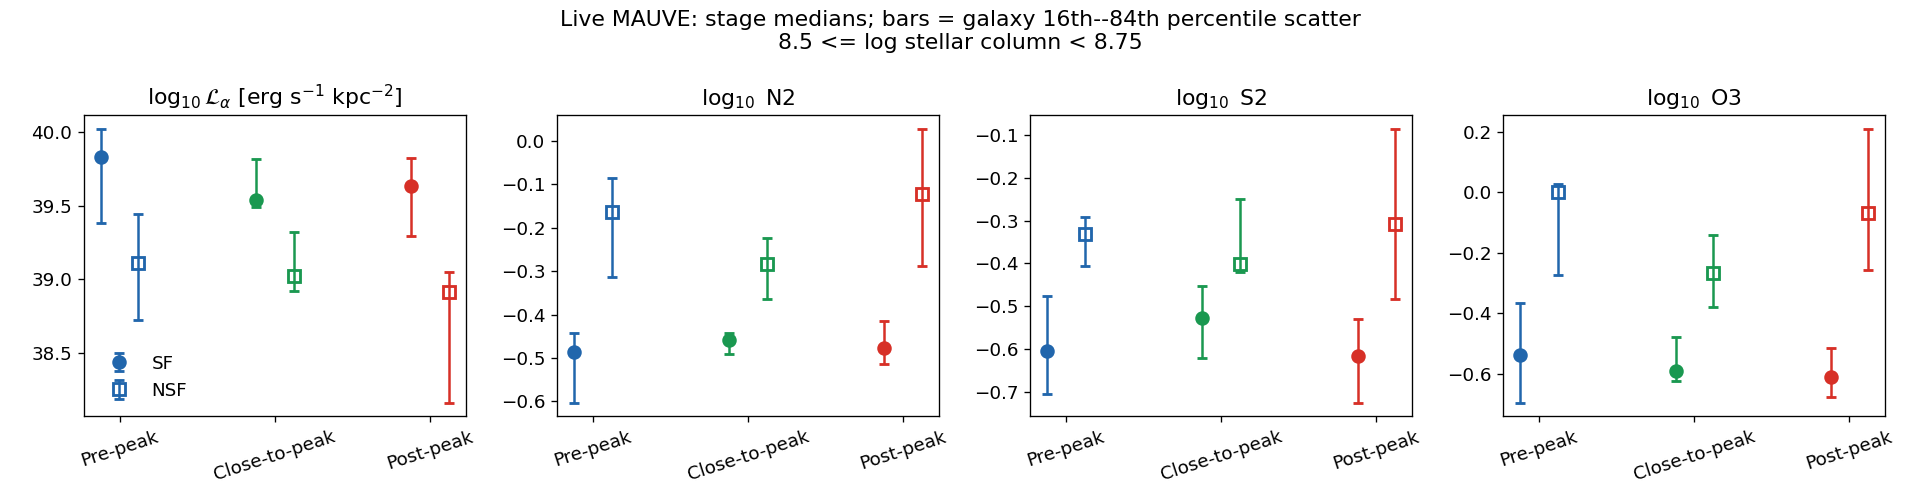

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for category, dx, marker in [('SF', -0.12, 'o'), ('NSF', 0.12, 's')]:
    for index, stage in enumerate(STAGES):
        row = OBS_STAGE.loc[(OBS_STAGE.stage == stage) & (OBS_STAGE.category == category)].iloc[0]
        group = OBS_BY_GALAXY.loc[(OBS_BY_GALAXY.stage == stage) &
                                  (OBS_BY_GALAXY.category == category) & OBS_BY_GALAXY.eligible]
        for ax, name in zip(axes, ('Halpha', 'N2', 'S2', 'O3')):
            values = group[name].to_numpy()
            lo, hi = np.percentile(np.log10(values), [16, 84])
            centre = np.log10(row[name])
            assert lo <= centre <= hi
            ax.errorbar(index+dx, centre, yerr=np.array([[centre-lo], [hi-centre]]),
                        fmt=marker, ms=7, color=STAGE_COLORS[stage],
                        markerfacecolor=STAGE_COLORS[stage] if category == 'SF' else 'none',
                        markeredgewidth=1.7, capsize=3, elinewidth=1.5,
                        label=category if index == 0 else None)
for ax, title in zip(axes, [r'$\log_{10}\mathcal{L}_\alpha$ [erg s$^{-1}$ kpc$^{-2}$]',
                            r'$\log_{10}$ N2', r'$\log_{10}$ S2', r'$\log_{10}$ O3']):
    ax.set_title(title)
    ax.set_xticks(range(3), ['Pre-peak', 'Close-to-peak', 'Post-peak'], rotation=18)
axes[0].legend(frameon=False)
fig.suptitle('Live MAUVE: stage medians; bars = galaxy 16th--84th percentile scatter\n8.5 <= log stellar column < 8.75')
fig.tight_layout()
plt.show()

## Normalize an illustrative NSF-like Composite initial state

We use the live pre-peak NSF median stellar column for the retained old-star normalization:

$$\mathcal L_\alpha^{\rm HOLMES}=\epsilon_\alpha q_{\rm H,HOLMES}f_{\rm old}\Sigma_*.$$

Both component spectra are explicit user-selected log10 ratio templates:
young N2 = -1.0, S2 = -1.2 and O3 = -0.5; HOLMES N2 = +0.25, S2 = +0.20 and O3 = +0.5.
We convert each log coordinate to a positive linear ratio using $R=10^{\log_{10}R}$.
Neither spectrum is estimated from the MAUVE ratios. These fixed spectra specify the
assumed mechanism; the real NSF medians remain comparison data.
We now set an explicit illustrative initial Balmer fraction $w_0=0.30$, keeping this
old-star luminosity fixed. Thus

$$\mathcal L_{\alpha,0}^{\rm model}=\mathcal L_\alpha^{\rm HOLMES}/w_0,\qquad
\mathcal L_{\alpha,0}^{\rm young}=\mathcal L_\alpha^{\rm HOLMES}(1-w_0)/w_0,$$
$$R_{\ell/B,0}^{\rm model}=(1-w_0)R_{\ell/B}^{\rm young}+w_0R_{\ell/B}^{\rm HOLMES}.$$

The code explicitly checks that the initial N2 BPT point lies between Ka03 and Ke01.
The model Halpha scale is printed alongside the actual measured NSF median; they are
distinct. This is a faint-NSF starting-condition experiment, not a measured 30% HOLMES
fraction or a fit to all three NSF median ratios. We do not raise the old-star fraction,
absorbed-photon fraction, or ionizing yield to force a brighter HOLMES luminosity.

The assumed feedback loading is now $\eta=3$ with outflow rate $\eta\Sigma_{\rm SFR}$.
HI stripping still has no direct molecular stripping term. Net molecular consumption
is $\gamma_{\rm H_2}=(1-R+\eta)/\tau_{\rm dep}=1.8$ Gyr$^{-1}$.
We derive $\Sigma_{{\rm SFR},0}=C_\alpha\mathcal L_{\alpha,0}^{\rm young}$ and
$\Sigma_{{\rm H_2},0}=10^3\tau_{\rm dep}\Sigma_{{\rm SFR},0}$, then set the balanced
reference $\tau_{\rm conv}=\Sigma_{{\rm HI},0}/(\gamma_{\rm H_2}\Sigma_{{\rm H_2},0})$.
The model-derived SFR/H2 columns are not measured NSF star-formation or CO columns.

Dots mark 0.5, 1.0, 1.5 and 2.0 Gyr. The temporal examples below vary only initial H2
at fixed coefficients; the emission/BPT calculations use this balanced NSF-like baseline.


In [5]:
# NSF supplies the old-stellar column and the real-data comparison scale.
observed_reference = OBS_STAGE.loc[(OBS_STAGE.stage == 'pre-peak') & (OBS_STAGE.category == 'NSF')].iloc[0]
# Both fixed component spectra are now explicit user-selected templates from cell 2.
if not all(0 < YOUNG_RATIOS[k] < HOLMES_RATIOS[k] for k in HOLMES_RATIOS):
    raise ValueError('Chosen HOLMES templates violate the assumed ratio ordering')

SIGMA_STAR = float(observed_reference.sigma_star)  # measured NSF column, Msun kpc^-2
L_ALPHA_OBS_0 = float(observed_reference.Halpha)   # actual NSF median, erg s^-1 kpc^-2
L_ALPHA_HOLMES = EPSILON_ALPHA*Q_H_HOLMES*F_OLD*SIGMA_STAR
W_HOLMES_OBS_SCALE = L_ALPHA_HOLMES/L_ALPHA_OBS_0
W_HOLMES_0 = INITIAL_HOLMES_FRACTION
if not 0 < W_HOLMES_0 < 1:
    raise ValueError('Initial HOLMES fraction must lie strictly between 0 and 1')
# Keep the adopted old-star photon budget; the higher fraction implies fainter total emission.
L_ALPHA_MODEL_0 = L_ALPHA_HOLMES/W_HOLMES_0
L_ALPHA_YOUNG_0 = L_ALPHA_MODEL_0-L_ALPHA_HOLMES
INITIAL_MODEL_RATIOS = {name: (1-W_HOLMES_0)*YOUNG_RATIOS[name]+W_HOLMES_0*value
                        for name,value in HOLMES_RATIOS.items()}
initial_n2, initial_o3 = np.log10(INITIAL_MODEL_RATIOS['N2']), np.log10(INITIAL_MODEL_RATIOS['O3'])
initial_ka03 = 0.61/(initial_n2-0.05)+1.30
initial_ke01 = 0.61/(initial_n2-0.47)+1.19
INITIAL_MODEL_IS_COMPOSITE = bool(initial_n2 < 0.05 and initial_ka03 < initial_o3 < initial_ke01)
if not INITIAL_MODEL_IS_COMPOSITE:
    raise ValueError('Initial model must lie between Ka03 and Ke01 in the N2 plane; inspect the assumed weight/templates')
SIGMA_SFR_0 = C_ALPHA*L_ALPHA_YOUNG_0
SIGMA_H2_0 = SIGMA_SFR_0*TAU_DEP*1e3
GAMMA_H2 = (1-RETURN_FRACTION+ETA)/TAU_DEP
TAU_CONV = SIGMA_HI_0/(GAMMA_H2*SIGMA_H2_0)
GAMMA_HI = 1/TAU_CONV+GAMMA_STRIP
print(f'Assumed eta = {ETA:g}; initial HOLMES fraction = {100*W_HOLMES_0:.1f}%')
print(f'Initial N2 BPT: x = {initial_n2:.6f}, y = {initial_o3:.6f}; '
      f'Ka03 = {initial_ka03:.6f} < y < Ke01 = {initial_ke01:.6f}: Composite')
print(f'At measured NSF median Halpha, the adopted photon budget gives '
      f'{100*W_HOLMES_OBS_SCALE:.3f}% HOLMES; the illustrative model Halpha is '
      f'{L_ALPHA_MODEL_0/L_ALPHA_OBS_0:.4f} times that measured median.')

def gas_solution(time_gyr, c_hi=1.0, gamma_strip=GAMMA_STRIP,
                 sigma_hi_0=SIGMA_HI_0, sigma_h2_0=SIGMA_H2_0):
    t = np.asarray(time_gyr, dtype=float)
    gamma_hi = 1/TAU_CONV+gamma_strip
    difference = gamma_hi-GAMMA_H2
    # Stable form of (exp(-gamma_HI*t)-exp(-gamma_H2*t))/(gamma_H2-gamma_HI).
    if np.isclose(difference, 0.0, rtol=0, atol=1e-12):
        response = t*np.exp(-GAMMA_H2*t)
    else:
        response = np.exp(-GAMMA_H2*t)*(-np.expm1(-difference*t))/difference
    hi = c_hi*sigma_hi_0*np.exp(-gamma_hi*t)
    supplied_h2 = c_hi*sigma_hi_0/TAU_CONV*response
    h2 = sigma_h2_0*np.exp(-GAMMA_H2*t)+supplied_h2
    return {'HI': hi, 'H2': h2, 'supply': hi/TAU_CONV,
            'supplied_H2': supplied_h2, 'SFR': h2/TAU_DEP*1e-3,
            'F_SFR': h2/sigma_h2_0, 'gamma_HI': gamma_hi}

reference = gas_solution(TIME_GYR)  # balanced baseline for the existing emission model
NO_RPS = gas_solution(TIME_GYR, gamma_strip=0.0)
# This comparison has the same initial columns but still has no external HI supply.
derived = pd.DataFrame([
    ('measured stellar column', SIGMA_STAR, 'Msun kpc^-2', 'live pre-peak NSF, median of product medians'),
    ('measured NSF median Halpha', L_ALPHA_OBS_0, 'erg s^-1 kpc^-2', 'live pre-peak NSF'),
    ('illustrative model initial total Halpha', L_ALPHA_MODEL_0, 'erg s^-1 kpc^-2', 'physical HOLMES floor / assumed initial weight'),
    ('HOLMES weight at observed NSF scale', W_HOLMES_OBS_SCALE, 'dimensionless', 'physical floor / measured NSF median'),
    ('assumed HOLMES Halpha floor', L_ALPHA_HOLMES, 'erg s^-1 kpc^-2', 'report eq. 33, f_old=1 and full absorption'),
    ('initial young Halpha', L_ALPHA_YOUNG_0, 'erg s^-1 kpc^-2', 'model total minus adopted stellar-mass floor'),
    ('initial HOLMES light fraction', W_HOLMES_0, 'dimensionless', 'assumed Composite starting fraction'),
    ('initial true model SFR', SIGMA_SFR_0, 'Msun yr^-1 kpc^-2', 'C_alpha times initial young Halpha'),
    ('initial molecular column', SIGMA_H2_0, 'Msun pc^-2', 'derived; not measured molecular gas'),
    ('conversion time', TAU_CONV, 'Gyr', 'derived initial balance'),
    ('molecular consumption rate', GAMMA_H2, 'Gyr^-1', '(1-R+eta)/tau_dep'),
    ('atomic removal rate', GAMMA_HI, 'Gyr^-1', '1/tau_conv + gamma_strip'),
    ('initial replenishment time', 1/GAMMA_H2, 'Gyr', 'balanced reference tau_Phi,0'),
], columns=['quantity','value','unit','provenance'])
display(derived)
display(pd.DataFrame({
    'young log10 ratio (assumed)': YOUNG_LOG_RATIOS,
    'HOLMES log10 ratio (assumed)': HOLMES_LOG_RATIOS,
    'young linear ratio (10**log)': YOUNG_RATIOS,
    'HOLMES linear ratio (10**log)': HOLMES_RATIOS}))
display(pd.DataFrame({
    'observed pre-peak NSF median (linear)': {k: float(observed_reference[k]) for k in HOLMES_RATIOS},
    'illustrative initial model mixture (linear)': INITIAL_MODEL_RATIOS}))

GAS_SYMBOLS = {'H2': r'$\Sigma_{\rm H_2}$', 'SFR': r'$\Sigma_{\rm SFR}$'}
LINE_SYMBOLS = {'Halpha': r'$\mathcal{L}_\alpha$', 'Hbeta': r'$\mathcal{L}_\beta$',
                'NII': r'$\mathcal{L}_{\rm [N\,II]}$', 'SII': r'$\mathcal{L}_{\rm [S\,II]}$',
                'OIII': r'$\mathcal{L}_{\rm [O\,III]}$'}
RATIO_SYMBOLS = {'N2': r'$R_{\rm [N\,II]/H\alpha}$',
                 'S2': r'$R_{\rm [S\,II]/H\alpha}$',
                 'O3': r'$R_{\rm [O\,III]/H\beta}$'}

def print_plot_initial(x, y, label, *, state=None, gamma_strip=GAMMA_STRIP,
                       units='dimensionless', model=True, zero_supply=False):
    """Print the first plotted point and the actual initial model settings."""
    x0, y0 = float(np.asarray(x).flat[0]), float(np.asarray(y).flat[0])
    print(f'\nBefore plotting {label}: first plotted x = {x0:.6g}; y = {y0:.6g} [{units}]')
    if not model:
        print('Observed diagnostic or boundary coordinates; no gas initial condition is assigned.')
        return
    if state is None:
        state = reference
    first = lambda key: float(np.asarray(state[key]).flat[0])
    supply0 = 0.0 if zero_supply else first('supply')
    print(f'Initial HI = {first("HI"):.6g}, H2 = {first("H2"):.6g} [Msun pc^-2]; '
          f'SFR = {first("SFR"):.6g} [Msun yr^-1 kpc^-2]; '
          f'molecular supply (Sigma_Phi) = {supply0:.6g}, '
          f'net consumption (gamma_H2 Sigma_H2) = {GAMMA_H2*first("H2"):.6g} '
          '[Msun pc^-2 Gyr^-1]')
    print(f'Settings: tau_dep = {TAU_DEP:g}, tau_conv = {TAU_CONV:.6g} [Gyr]; '
          f'R = {RETURN_FRACTION:g}, eta = {ETA:g}; gamma_strip = {gamma_strip:g} [Gyr^-1]; '
          f'Sigma_star = {SIGMA_STAR:.6g} [Msun kpc^-2]; f_old = {F_OLD:g}')
    if 'EMISSION' in globals():
        print(f'Initial Halpha: young = {L_ALPHA_YOUNG_0:.6g}, HOLMES = {L_ALPHA_HOLMES:.6g}, '
              f'model total = {L_ALPHA_MODEL_0:.6g} [erg s^-1 kpc^-2]; '
              f'HOLMES weight = {W_HOLMES_0:.6g}; '
              f'young ratios = {YOUNG_RATIOS}; HOLMES ratios = {HOLMES_RATIOS}')
        print(f'Assumed log10 templates: young = {YOUNG_LOG_RATIOS}; HOLMES = {HOLMES_LOG_RATIOS}')


Assumed eta = 3; initial HOLMES fraction = 30.0%
Initial N2 BPT: x = -0.219334, y = 0.068202; Ka03 = -0.964843 < y < Ke01 = 0.305088: Composite
At measured NSF median Halpha, the adopted photon budget gives 2.960% HOLMES; the illustrative model Halpha is 0.0987 times that measured median.


                                   quantity  ...                                      provenance
0                   measured stellar column  ...    live pre-peak NSF, median of product medians
1                measured NSF median Halpha  ...                               live pre-peak NSF
2   illustrative model initial total Halpha  ...  physical HOLMES floor / assumed initial weight
3       HOLMES weight at observed NSF scale  ...            physical floor / measured NSF median
4               assumed HOLMES Halpha floor  ...      report eq. 33, f_old=1 and full absorption
5                      initial young Halpha  ...    model total minus adopted stellar-mass floor
6             initial HOLMES light fraction  ...             assumed Composite starting fraction
7                    initial true model SFR  ...              C_alpha times initial young Halpha
8                  initial molecular column  ...             derived; not measured molecular gas
9                           co

    young log10 ratio (assumed)  ...  HOLMES linear ratio (10**log)
N2                         -1.0  ...                       1.778279
S2                         -1.2  ...                       1.584893
O3                         -0.5  ...                       3.162278

[3 rows x 4 columns]

    observed pre-peak NSF median (linear)  illustrative initial model mixture (linear)
N2                               0.685776                                     0.603484
S2                               0.465814                                     0.519635
O3                               1.002714                                     1.170043


Before plotting Atomic gas ($\Sigma_{\rm HI}$): first plotted x = 0; y = 10 [Msun pc^-2]
Initial HI = 10, H2 = 0.882586 [Msun pc^-2]; SFR = 0.000441293 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 1.58866, net consumption (gamma_H2 Sigma_H2) = 1.58866 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1

Before plotting Molecular gas ($\Sigma_{\rm H_2}$): first plotted x = 0; y = 0.882586 [Msun pc^-2]
Initial HI = 10, H2 = 0.882586 [Msun pc^-2]; SFR = 0.000441293 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 1.58866, net consumption (gamma_H2 Sigma_H2) = 1.58866 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1

Before plotting Molecular supply ($\Sigma_\Phi$): first plotted x = 0; y = 1.58866 [Msun pc^-2 Gyr^-1]
Initial HI = 10, H2 = 0.882586 [Msun pc^

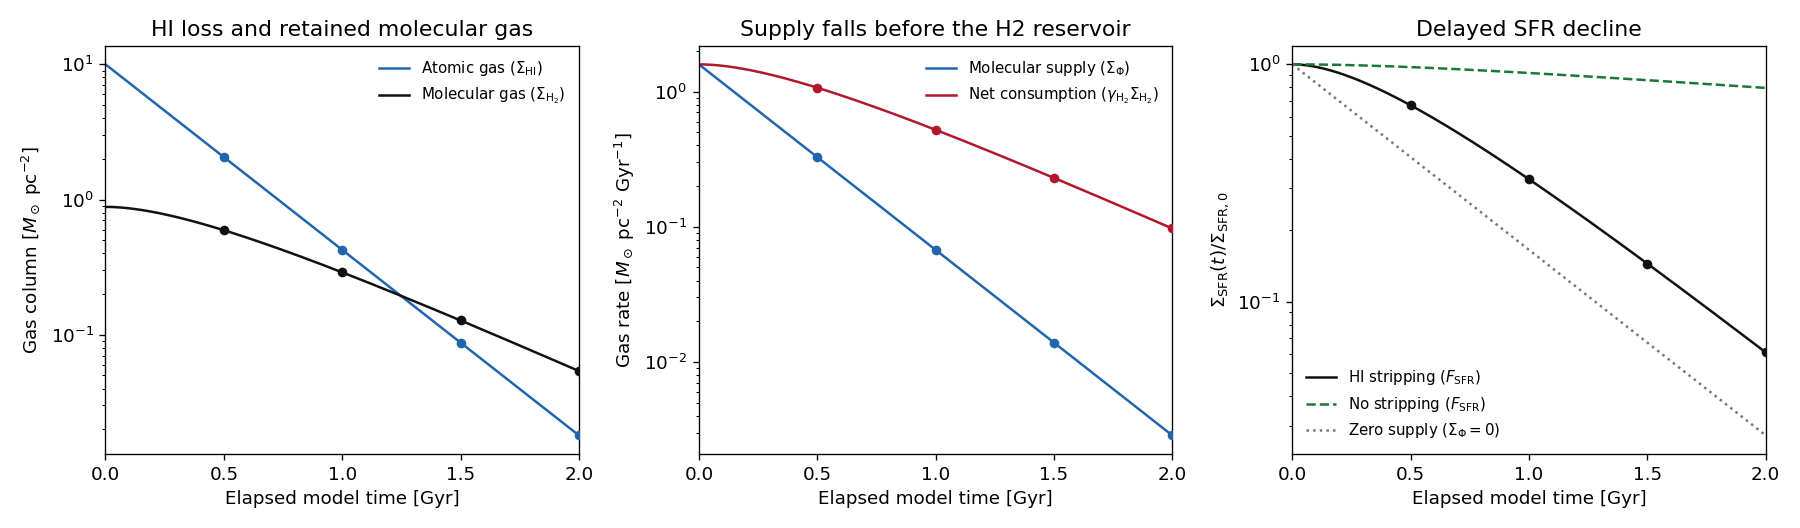

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
print_plot_initial(TIME_GYR, reference['HI'], r'Atomic gas ($\Sigma_{\rm HI}$)', units='Msun pc^-2')
axes[0].plot(TIME_GYR, reference['HI'], color='#2166ac', label=r'Atomic gas ($\Sigma_{\rm HI}$)')
print_plot_initial(TIME_GYR, reference['H2'], r'Molecular gas ($\Sigma_{\rm H_2}$)', units='Msun pc^-2')
axes[0].plot(TIME_GYR, reference['H2'], color='#111111', label=r'Molecular gas ($\Sigma_{\rm H_2}$)')
axes[0].set_ylabel(r'Gas column [$M_\odot$ pc$^{-2}$]')
axes[0].set_title('HI loss and retained molecular gas')
print_plot_initial(TIME_GYR, reference['supply'], r'Molecular supply ($\Sigma_\Phi$)', units='Msun pc^-2 Gyr^-1')
axes[1].plot(TIME_GYR, reference['supply'], color='#2166ac', label=r'Molecular supply ($\Sigma_\Phi$)')
print_plot_initial(TIME_GYR, GAMMA_H2*reference['H2'], r'Net consumption ($\gamma_{\rm H_2}\Sigma_{\rm H_2}$)', units='Msun pc^-2 Gyr^-1')
axes[1].plot(TIME_GYR, GAMMA_H2*reference['H2'], color='#b2182b', label=r'Net consumption ($\gamma_{\rm H_2}\Sigma_{\rm H_2}$)')
axes[1].set_ylabel(r'Gas rate [$M_\odot$ pc$^{-2}$ Gyr$^{-1}$]')
axes[1].set_title('Supply falls before the H2 reservoir')
print_plot_initial(TIME_GYR, reference['F_SFR'], r'HI stripping ($F_{\rm SFR}$)', units='dimensionless')
axes[2].plot(TIME_GYR, reference['F_SFR'], color='#111111', label=r'HI stripping ($F_{\rm SFR}$)')
print_plot_initial(TIME_GYR, NO_RPS['F_SFR'], r'No stripping ($F_{\rm SFR}$)', units='dimensionless', state=NO_RPS, gamma_strip=0.0)
axes[2].plot(TIME_GYR, NO_RPS['F_SFR'], '--', color='#1b7837', label=r'No stripping ($F_{\rm SFR}$)')
print_plot_initial(TIME_GYR, np.exp(-GAMMA_H2*TIME_GYR), r'Zero supply ($\Sigma_\Phi=0$)', units='dimensionless', zero_supply=True)
axes[2].plot(TIME_GYR, np.exp(-GAMMA_H2*TIME_GYR), ':', color='#777777', label=r'Zero supply ($\Sigma_\Phi=0$)')
axes[2].set_ylabel(r'$\Sigma_{\rm SFR}(t)/\Sigma_{{\rm SFR},0}$')
axes[2].set_title('Delayed SFR decline')
for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Elapsed model time [Gyr]')
    format_time_axis(ax)
    ax.legend(frameon=False, fontsize=9)
mark_time_checkpoints(axes[0], reference['HI'], '#2166ac')
mark_time_checkpoints(axes[0], reference['H2'], '#111111')
mark_time_checkpoints(axes[1], reference['supply'], '#2166ac')
mark_time_checkpoints(axes[1], GAMMA_H2*reference['H2'], '#b2182b')
mark_time_checkpoints(axes[2], reference['F_SFR'], '#111111')
fig.tight_layout()
plt.show()
print(f'At 2 Gyr: reference remaining SFR = {reference["F_SFR"][-1]:.4f}; '
      f'zero-supply bound = {np.exp(-GAMMA_H2*TIME_GYR[-1]):.4f}')

## Temporal response: two initial conditions, without a spatial comparison

This is the **time history at one reference position**. We set $c_{\rm HI}=1$ in both
examples and hold $\Sigma_{{\rm HI},0}$, $\tau_{\rm conv}$, $\tau_{\rm dep}$, $R$,
$\eta$, and $\gamma_{\rm strip}$ fixed. We vary only $\Sigma_{{\rm H_2},0}$:
the declining example starts with **2.0 times**, and the initially rising example with
**0.4 times**, the data-normalized baseline molecular column. These are illustrative
initial conditions, not molecular-gas measurements. The conversion time remains the
one already derived for the balanced baseline; it is not retuned to rebalance each example.

From report sections 3.3--3.4, equations (16)--(25), define the initial supply and
replenishment time by

$$\Sigma_{\Phi,0}=\frac{\Sigma_{{\rm HI},0}}{\tau_{\rm conv}},\qquad
\tau_{\Phi,0}=\frac{\Sigma_{{\rm H_2},0}}{\Sigma_{\Phi,0}}.$$

Then the temporal sign is

$$\frac{1}{\Sigma_{{\rm SFR},0}}
\left.\frac{d\Sigma_{\rm SFR}}{dt}\right|_{t=0}
=\frac{1}{\tau_{\Phi,0}}-\gamma_{\rm H_2}.$$

For $1/\tau_{\Phi,0}\leq\gamma_{\rm H_2}$, H$_2$ and SFR decrease monotonically
(the equality case starts with zero slope). For $1/\tau_{\Phi,0}>\gamma_{\rm H_2}$,
both initially rise, reach a common temporal maximum, and then decline as the HI supply fades.
With constant $\tau_{\rm dep}$, their fractional histories are identical. The reference
histories here are not called leading or trailing.

Setting $\frac{d\Sigma_{\rm H_2}}{dt}=0$ in the explicit solution gives report equation (24):

$$t_{\rm peak}=\frac{1}{\gamma_{\rm HI}-\gamma_{\rm H_2}}
\ln\!\left[\frac{\gamma_{\rm HI}}
{\gamma_{\rm H_2}\{1+(\gamma_{\rm HI}-\gamma_{\rm H_2})\tau_{\Phi,0}\}}\right].$$

The peak is positive in the initially rising case. For equal removal rates its finite
limit is $t_{\rm peak}=1/\gamma_{\rm H_2}-\tau_{\Phi,0}$. The code marks this maximum
and uses an early-time inset to resolve the rise and turnover. These temporal examples
are independent of the **spatial** offsets in the next section. The emission-line and
BPT calculations later continue to use the original balanced, data-normalized baseline.



Before plotting Monotonic decline ($\Sigma_{\rm H_2}$): first plotted x = 0; y = 1.76517 [Msun pc^-2]
Initial HI = 10, H2 = 1.76517 [Msun pc^-2]; SFR = 0.000882586 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 1.58866, net consumption (gamma_H2 Sigma_H2) = 3.17731 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1

Before plotting Monotonic decline ($\Sigma_{\rm SFR}$): first plotted x = 0; y = 0.000882586 [Msun yr^-1 kpc^-2]
Initial HI = 10, H2 = 1.76517 [Msun pc^-2]; SFR = 0.000882586 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 1.58866, net consumption (gamma_H2 Sigma_H2) = 3.17731 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1

Before plotting Initial rise then decline ($\Sigma_{\rm H_2}$): first plotted x = 0; y = 0.353035 [Msun pc^-2]
Initial

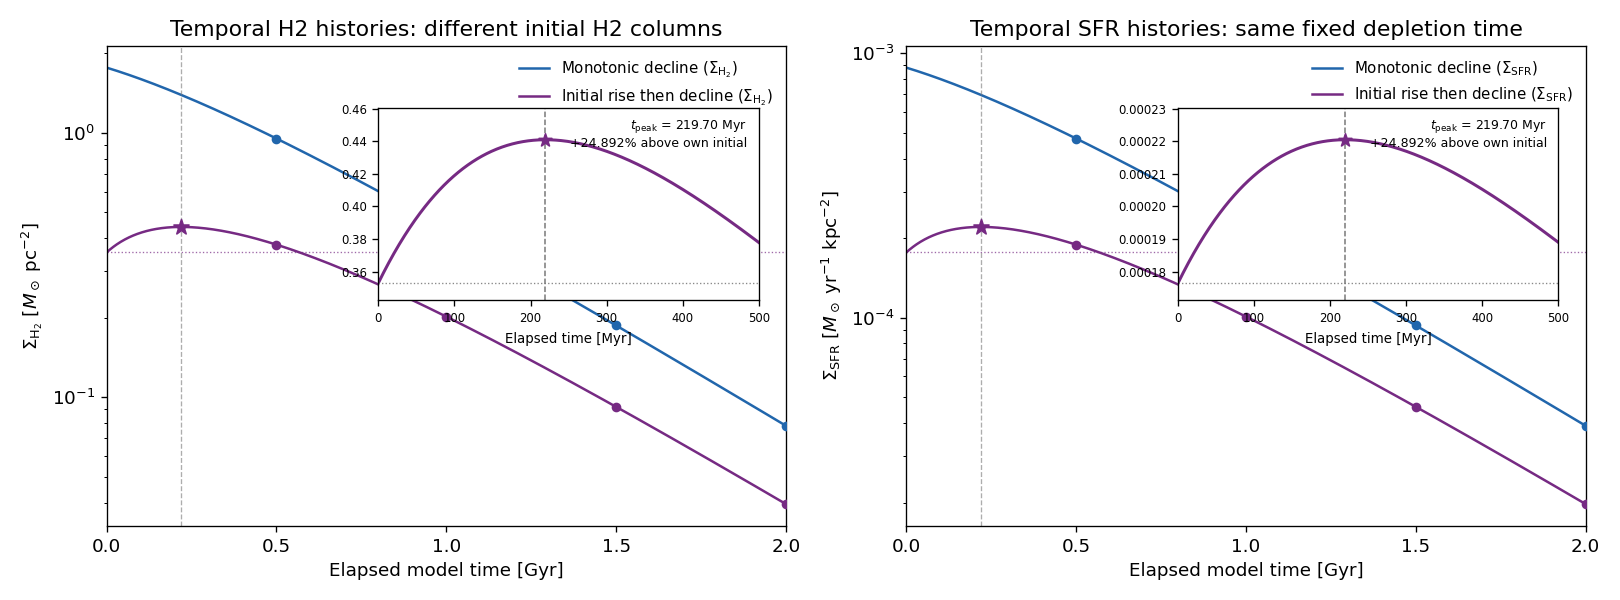

<IPython.core.display.Markdown object>

      initial_condition_case  HI_0_Msun_pc2  H2_0_Msun_pc2  \
0          Monotonic decline           10.0       1.765173   
1  Initial rise then decline           10.0       0.353035   

   SFR_0_Msun_yr_kpc2  tau_Phi_0_Gyr  initial_fractional_slope_Gyr^-1  \
0            0.000883       1.111111                             -0.9   
1            0.000177       0.222222                              2.7   

   temporal_peak_time_Gyr  peak_fraction_of_own_initial  remaining_at_2Gyr  
0                0.000000                      1.000000           0.044226  
1                0.219704                      1.248917           0.111834  

      initial_condition_case  ...  fraction_of_own_initial
0          Monotonic decline  ...                 0.539349
1          Monotonic decline  ...                 0.246648
2          Monotonic decline  ...                 0.105919
3          Monotonic decline  ...                 0.044226
4  Initial rise then decline  ...                 1.070469
5  Initial rise then decline  ...                 0.572044
6  Initial rise then decline  ...                 0.260774
7  Initial rise then decline  ...                 0.111834

[8 rows x 5 columns]

In [7]:
TEMPORAL_INITIAL_H2 = {
    'Monotonic decline': 2.0*SIGMA_H2_0,
    'Initial rise then decline': 0.4*SIGMA_H2_0,
}
TEMPORAL_COLORS = {'Monotonic decline': '#2166ac', 'Initial rise then decline': '#762a83'}
TEMPORAL_GAS = {case: gas_solution(TIME_GYR, sigma_h2_0=initial_h2)
                for case,initial_h2 in TEMPORAL_INITIAL_H2.items()}

def molecular_peak_time(sigma_h2_0, sigma_hi_0=SIGMA_HI_0, c_hi=1.0):
    """Temporal maximum for specified initial gas columns; report equation (24)."""
    supply_0 = c_hi*sigma_hi_0/TAU_CONV
    if supply_0 <= GAMMA_H2*sigma_h2_0:
        return 0.0
    tau_phi_0 = sigma_h2_0/supply_0
    rate_difference = GAMMA_HI-GAMMA_H2
    if np.isclose(rate_difference, 0.0, rtol=0, atol=1e-12):
        return 1/GAMMA_H2-tau_phi_0
    return np.log(GAMMA_HI/(GAMMA_H2*(1+rate_difference*tau_phi_0)))/rate_difference

temporal_rows = []
for case,initial_h2 in TEMPORAL_INITIAL_H2.items():
    peak = molecular_peak_time(initial_h2)
    peak_state = gas_solution(peak, sigma_h2_0=initial_h2)
    tau_phi_0 = initial_h2/(SIGMA_HI_0/TAU_CONV)
    temporal_rows.append({
        'initial_condition_case': case, 'HI_0_Msun_pc2': SIGMA_HI_0,
        'H2_0_Msun_pc2': initial_h2, 'SFR_0_Msun_yr_kpc2': initial_h2/TAU_DEP*1e-3,
        'tau_Phi_0_Gyr': tau_phi_0, 'initial_fractional_slope_Gyr^-1': 1/tau_phi_0-GAMMA_H2,
        'temporal_peak_time_Gyr': peak, 'peak_fraction_of_own_initial': float(peak_state['F_SFR']),
        'remaining_at_2Gyr': float(TEMPORAL_GAS[case]['F_SFR'][-1])})
TEMPORAL_SUMMARY = pd.DataFrame(temporal_rows)
rising_case = 'Initial rise then decline'
rising_initial_h2 = TEMPORAL_INITIAL_H2[rising_case]
temporal_peak = molecular_peak_time(rising_initial_h2)
temporal_peak_state = gas_solution(temporal_peak, sigma_h2_0=rising_initial_h2)
zoom_end = min(0.5, 2.5*temporal_peak)
zoom_time = np.linspace(0.0, zoom_end, 801)
zoom_rising = gas_solution(zoom_time, sigma_h2_0=rising_initial_h2)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
for case,values in TEMPORAL_GAS.items():
    color = TEMPORAL_COLORS[case]
    for ax,key in zip(axes, ('H2','SFR')):
        print_plot_initial(TIME_GYR, values[key], case+' ('+GAS_SYMBOLS[key]+')', units='Msun pc^-2' if key == 'H2' else 'Msun yr^-1 kpc^-2', state=values)
        ax.plot(TIME_GYR, values[key], color=color, label=case+' ('+GAS_SYMBOLS[key]+')')
        mark_time_checkpoints(ax, values[key], color)
for ax,key,ylabel in zip(axes, ('H2','SFR'), (
        r'$\Sigma_{\rm H_2}$ [$M_\odot$ pc$^{-2}$]',
        r'$\Sigma_{\rm SFR}$ [$M_\odot$ yr$^{-1}$ kpc$^{-2}$]')):
    ax.set_yscale('log')
    ax.set(xlabel='Elapsed model time [Gyr]', ylabel=ylabel)
    initial = float(TEMPORAL_GAS[rising_case][key][0])
    ax.axhline(initial, color=TEMPORAL_COLORS[rising_case], ls=':', lw=0.8, alpha=0.7)
    ax.axvline(temporal_peak, color='#777777', ls='--', lw=0.8, alpha=0.6)
    ax.scatter(temporal_peak, temporal_peak_state[key], color=TEMPORAL_COLORS[rising_case],
               marker='*', s=90, zorder=5)
    zoom = ax.inset_axes([0.40, 0.47, 0.56, 0.40])
    print_plot_initial(zoom_time*1000, zoom_rising[key], 'Curve in cell 12', units='Msun pc^-2' if key == 'H2' else 'Msun yr^-1 kpc^-2', state=zoom_rising)
    zoom.plot(zoom_time*1000, zoom_rising[key], color=TEMPORAL_COLORS[rising_case], lw=1.8)
    zoom.axhline(initial, color='#888888', ls=':', lw=0.8)
    zoom.axvline(temporal_peak*1000, color='#777777', ls='--', lw=0.9)
    zoom.scatter(temporal_peak*1000, temporal_peak_state[key], color=TEMPORAL_COLORS[rising_case],
                 marker='*', s=65, zorder=5)
    zoom.set_xlim(0, zoom_end*1000)
    span = np.ptp(zoom_rising[key])
    zoom.set_ylim(zoom_rising[key].min()-0.12*span, zoom_rising[key].max()+0.22*span)
    zoom.text(0.97, 0.95, rf'$t_{{\rm peak}}$ = {temporal_peak*1000:.2f} Myr'+'\n'+
              f'+{100*(temporal_peak_state["F_SFR"]-1):.3f}% above own initial',
              transform=zoom.transAxes, ha='right', va='top', fontsize=7.5)
    zoom.set(xlabel='Elapsed time [Myr]')
    zoom.xaxis.label.set_size(8)
    zoom.tick_params(labelsize=7)
    zoom.ticklabel_format(useOffset=False)
    format_time_axis(ax)
    ax.legend(frameon=False, fontsize=9, loc='upper right')
axes[0].set_title('Temporal H2 histories: different initial H2 columns')
axes[1].set_title('Temporal SFR histories: same fixed depletion time')
fig.tight_layout()
plt.show()
display(Markdown('**Initial-condition response; no leading/trailing perturbation is applied here.**'))
with pd.option_context('display.max_columns', None):
    display(TEMPORAL_SUMMARY)
temporal_checkpoint_rows = []
for case,initial_h2 in TEMPORAL_INITIAL_H2.items():
    for time in CHECKPOINT_TIMES:
        state = gas_solution(time, sigma_h2_0=initial_h2)
        temporal_checkpoint_rows.append({
            'initial_condition_case': case, 'time_Gyr': time,
            'H2_Msun_pc2': float(state['H2']), 'SFR_Msun_yr_kpc2': float(state['SFR']),
            'fraction_of_own_initial': float(state['F_SFR'])})
TEMPORAL_CHECKPOINTS = pd.DataFrame(temporal_checkpoint_rows)
display(TEMPORAL_CHECKPOINTS)


## Spatial comparison: apply leading/trailing HI factors to either temporal reference

Now compare **positions at the same time**, separately for each of the two initial-condition
cases above. Within a case, leading/reference/trailing positions share the same initial
H$_2$ column and all coefficients. Only the initial HI column is multiplied by
$c_{\rm HI}=1.5,1,0.5$, respectively. Different rows of the figure have different common
initial H$_2$ columns, so each row has its own contemporaneous reference history.

The report's section 3.5, equations (27)--(30), gives for either reference history

$$\Sigma_{\rm H_2}(x,t)-\Sigma_{\rm H_2}^{\rm reference}(t)
=[c_{\rm HI}(x)-1]\left[\Sigma_{\rm H_2}^{\rm reference}(t)
-\Sigma_{{\rm H_2},0}e^{-\gamma_{\rm H_2}t}\right].$$

The bracket is the positive surviving molecular gas supplied after $t=0$. Therefore
$c_{\rm HI}>1$ lies above its matched reference, and $c_{\rm HI}<1$ lies below it for
every $t>0$, **whether that reference declines monotonically or initially rises**.
At $t=0$, all three positions have equal H$_2$/SFR within each case.

The spatial SFR contrast is

$$\Delta\log_{10}\Sigma_{\rm SFR}(x,t)
=\log_{10}\!\left[\frac{\Sigma_{\rm SFR}(x,t)}
{\Sigma_{\rm SFR}^{\rm reference}(t)}\right].$$

A positive spatial contrast does not imply a positive temporal derivative:

$$\left.\frac{d\Sigma_{\rm H_2}(x,t)}{dt}\right|_{t=0}
=c_{\rm HI}(x)\frac{\Sigma_{{\rm HI},0}}{\tau_{\rm conv}}
-\gamma_{\rm H_2}\Sigma_{{\rm H_2},0}.$$

The assumed initial columns were chosen so that all three spatial positions decline
in the first case, and all three initially rise before declining in the second.
Both rows nevertheless satisfy leading > reference > trailing for $t>0$. Thus spatial
enhancement/suppression is a comparison with the simultaneous reference, while an initial
rise/fall concerns a region's own time history. The table below reports the former;
temporal maxima are reported in the preceding section. These factors illustrate the
report's spatial mechanism and are not fitted NGC4654 measurements.



Before plotting Trailing ($c_{\rm HI}=0.5$) ($\Sigma_{\rm H_2}$): first plotted x = 0; y = 1.76517 [Msun pc^-2]
Initial HI = 5, H2 = 1.76517 [Msun pc^-2]; SFR = 0.000882586 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 0.794328, net consumption (gamma_H2 Sigma_H2) = 3.17731 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1

Before plotting Trailing ($c_{\rm HI}=0.5$) ($\Sigma_{\rm SFR}$): first plotted x = 0; y = 0.000882586 [Msun yr^-1 kpc^-2]
Initial HI = 5, H2 = 1.76517 [Msun pc^-2]; SFR = 0.000882586 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 0.794328, net consumption (gamma_H2 Sigma_H2) = 3.17731 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1

Before plotting Trailing ($c_{\rm HI}=0.5$) ($\Delta\log_{10}\Sigma_{\rm SFR}$): first plotted x =

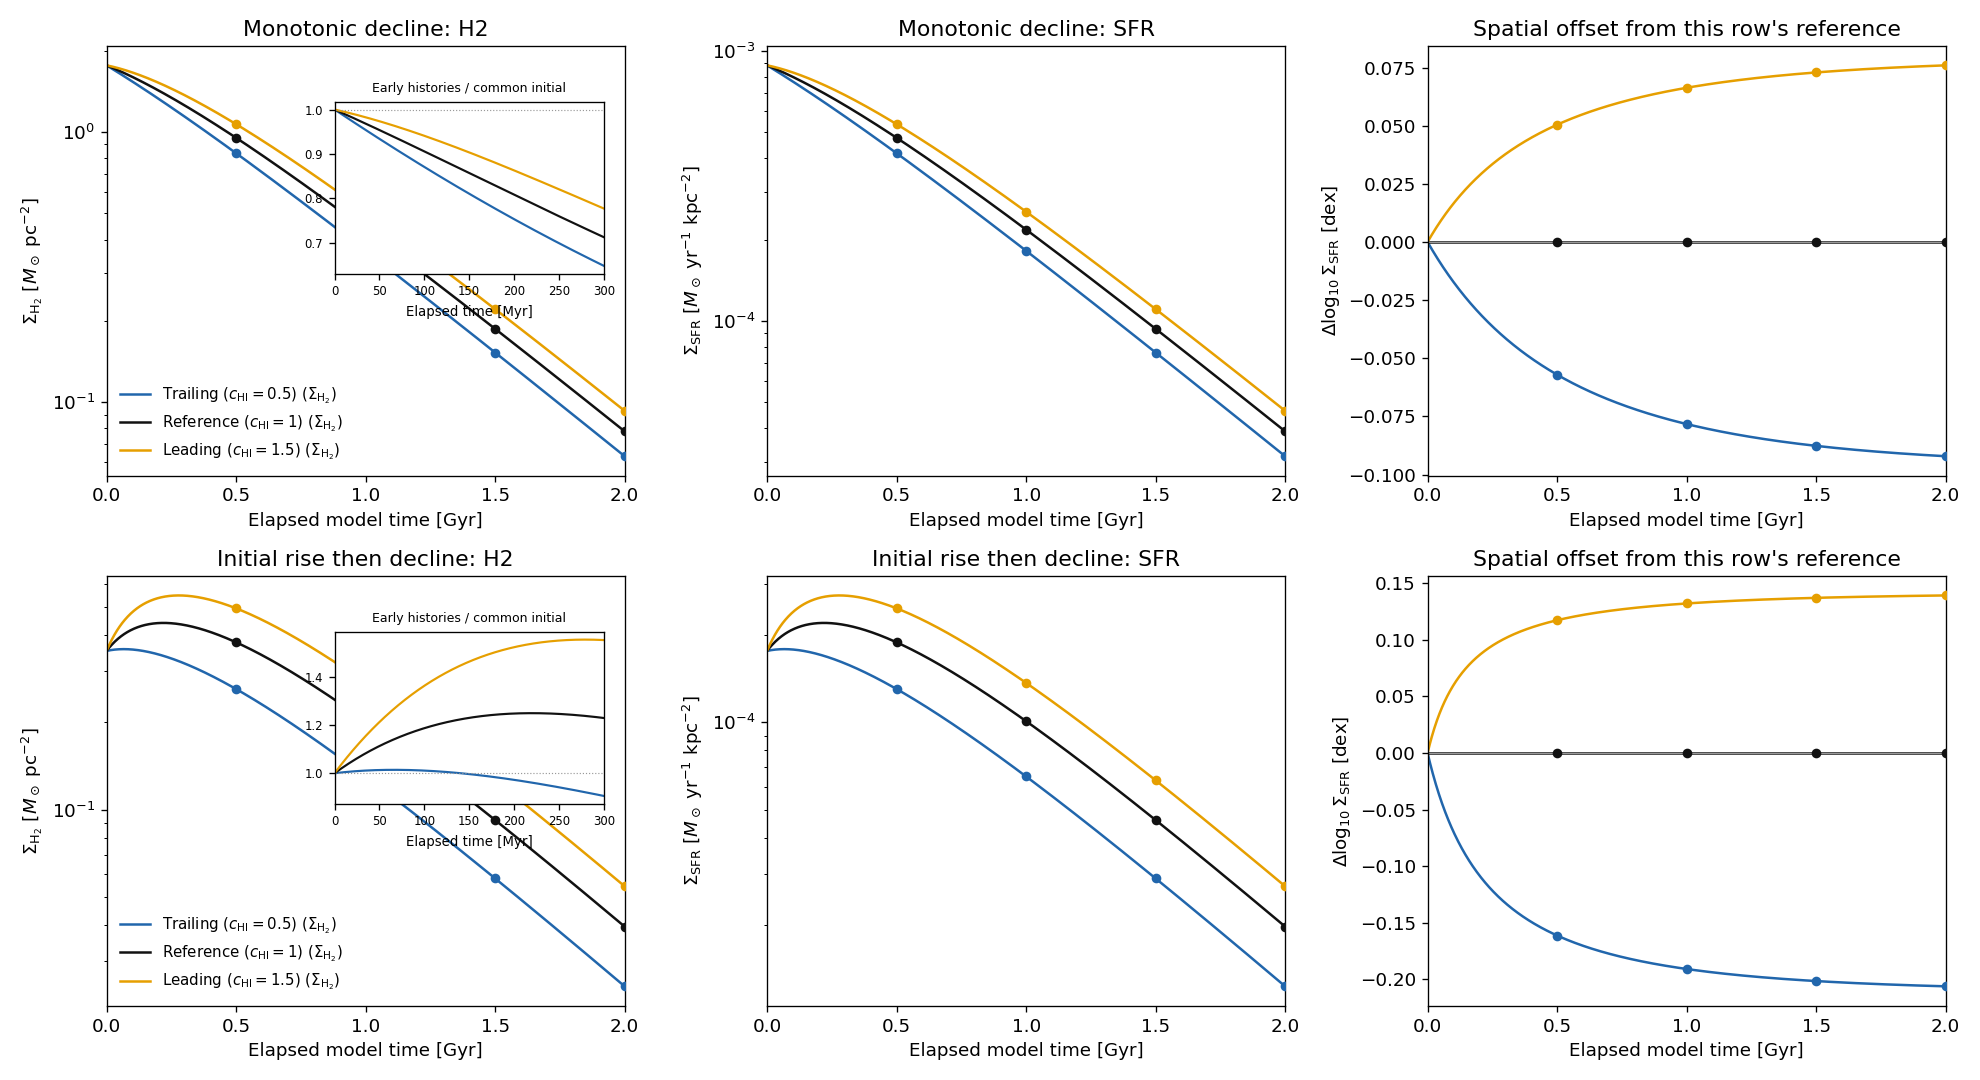

<IPython.core.display.Markdown object>

      reference_history_case   position  c_HI  common_initial_H2_Msun_pc2  \
0          Monotonic decline   trailing   0.5                    1.765173   
1          Monotonic decline  reference   1.0                    1.765173   
2          Monotonic decline    leading   1.5                    1.765173   
3  Initial rise then decline   trailing   0.5                    0.353035   
4  Initial rise then decline  reference   1.0                    0.353035   
5  Initial rise then decline    leading   1.5                    0.353035   

   initial_temporal_fractional_slope_Gyr^-1  \
0                                     -1.35   
1                                     -0.90   
2                                     -0.45   
3                                      0.45   
4                                      2.70   
5                                      4.95   

   offset_from_matched_reference_2Gyr_dex  own_remaining_SFR_2Gyr  
0                               -0.092099                0.035

       reference_history_case  time_Gyr   position  c_HI  HI_Msun_pc2  \
0           Monotonic decline       0.5   trailing   0.5     1.030460   
1           Monotonic decline       1.0   trailing   0.5     0.212369   
2           Monotonic decline       1.5   trailing   0.5     0.043768   
3           Monotonic decline       2.0   trailing   0.5     0.009020   
4           Monotonic decline       0.5  reference   1.0     2.060920   
5           Monotonic decline       1.0  reference   1.0     0.424739   
6           Monotonic decline       1.5  reference   1.0     0.087535   
7           Monotonic decline       2.0  reference   1.0     0.018040   
8           Monotonic decline       0.5    leading   1.5     3.091379   
9           Monotonic decline       1.0    leading   1.5     0.637108   
10          Monotonic decline       1.5    leading   1.5     0.131303   
11          Monotonic decline       2.0    leading   1.5     0.027060   
12  Initial rise then decline       0.5   trailing 

In [8]:
SPATIAL_GAS = {
    case: {region: gas_solution(TIME_GYR, c_hi=c, sigma_h2_0=initial_h2)
           for region,c in ATOMIC_FACTORS.items()}
    for case,initial_h2 in TEMPORAL_INITIAL_H2.items()}
fig, axes = plt.subplots(2, 3, figsize=(16.5, 9.0))
spatial_rows, spatial_checkpoint_rows = [], []
for row,(case,initial_h2) in enumerate(TEMPORAL_INITIAL_H2.items()):
    matched_reference = SPATIAL_GAS[case]['reference']
    for region,c in ATOMIC_FACTORS.items():
        values = SPATIAL_GAS[case][region]
        color = MODEL_COLORS[region]
        label = rf'{region.capitalize()} ($c_{{\rm HI}}={c:g}$)'
        offset = np.log10(values['SFR']/matched_reference['SFR'])
        for ax,history,symbol in zip(axes[row], (values['H2'],values['SFR'],offset),
                (GAS_SYMBOLS['H2'], GAS_SYMBOLS['SFR'], r'$\Delta\log_{10}\Sigma_{\rm SFR}$')):
            print_plot_initial(TIME_GYR, history, label+' ('+symbol+')', units=('Msun pc^-2' if symbol == GAS_SYMBOLS['H2'] else 'Msun yr^-1 kpc^-2' if symbol == GAS_SYMBOLS['SFR'] else 'dex'), state=values)
            ax.plot(TIME_GYR, history, color=color, label=label+' ('+symbol+')')
            mark_time_checkpoints(ax, history, color)
        temporal_slope = c*SIGMA_HI_0/(TAU_CONV*initial_h2)-GAMMA_H2
        spatial_rows.append({
            'reference_history_case': case, 'position': region, 'c_HI': c,
            'common_initial_H2_Msun_pc2': initial_h2,
            'initial_temporal_fractional_slope_Gyr^-1': temporal_slope,
            'offset_from_matched_reference_2Gyr_dex': float(offset[-1]),
            'own_remaining_SFR_2Gyr': float(values['F_SFR'][-1])})
        for time in CHECKPOINT_TIMES:
            local = gas_solution(time, c_hi=c, sigma_h2_0=initial_h2)
            simultaneous = gas_solution(time, sigma_h2_0=initial_h2)
            spatial_checkpoint_rows.append({
                'reference_history_case': case, 'time_Gyr': time, 'position': region, 'c_HI': c,
                'HI_Msun_pc2': float(local['HI']), 'H2_Msun_pc2': float(local['H2']),
                'SFR_Msun_yr_kpc2': float(local['SFR']), 'fraction_of_own_initial': float(local['F_SFR']),
                'offset_from_matched_reference_dex': float(np.log10(local['SFR']/simultaneous['SFR']))})
    for ax in axes[row,:2]:
        ax.set_yscale('log')
    axes[row,0].set_ylabel(r'$\Sigma_{\rm H_2}$ [$M_\odot$ pc$^{-2}$]')
    axes[row,1].set_ylabel(r'$\Sigma_{\rm SFR}$ [$M_\odot$ yr$^{-1}$ kpc$^{-2}$]')
    axes[row,2].set_ylabel(r'$\Delta\log_{10}\Sigma_{\rm SFR}$ [dex]')
    axes[row,2].axhline(0, color='#999999', lw=0.7)
    for ax in axes[row]:
        ax.set_xlabel('Elapsed model time [Gyr]')
        format_time_axis(ax)
    axes[row,0].set_title(case+': H2')
    axes[row,1].set_title(case+': SFR')
    axes[row,2].set_title('Spatial offset from this row\'s reference')
    axes[row,0].legend(frameon=False, fontsize=9, loc='lower left')
    # Show early spatial separation without using a temporal peak as its definition.
    zoom = axes[row,0].inset_axes([0.44, 0.47, 0.52, 0.40])
    early_time = np.linspace(0, 0.30, 601)
    for region,c in ATOMIC_FACTORS.items():
        local = gas_solution(early_time, c_hi=c, sigma_h2_0=initial_h2)
        print_plot_initial(early_time*1000, local['F_SFR'], region+' early normalized SFR', units='dimensionless', state=local)
        zoom.plot(early_time*1000, local['F_SFR'], color=MODEL_COLORS[region], lw=1.3)
    zoom.axhline(1, color='#999999', ls=':', lw=0.7)
    zoom.set(xlim=(0,300), xlabel='Elapsed time [Myr]')
    zoom.set_title('Early histories / common initial', fontsize=7.5)
    zoom.xaxis.label.set_size(8)
    zoom.tick_params(labelsize=7)
    zoom.ticklabel_format(useOffset=False)
fig.tight_layout()
plt.show()
SPATIAL_SUMMARY = pd.DataFrame(spatial_rows)
SPATIAL_CHECKPOINTS = pd.DataFrame(spatial_checkpoint_rows)
display(Markdown('**Spatial contrasts for both reference histories. Temporal slope and spatial offset are separate columns.**'))
with pd.option_context('display.max_columns', None, 'display.max_rows', None):
    display(SPATIAL_SUMMARY)
    display(SPATIAL_CHECKPOINTS)


## Connect SFR to the luminosity budget

We use the report's instantaneous young-star H$\alpha$ approximation, equations (31)--(40).
It is appropriate here because the imposed gas evolution is slower than the massive-star
response. For any remaining-SFR fraction $F$,

$$\mathcal L_\alpha^{\rm young}=\mathcal L_{\alpha,0}^{\rm young}F,\qquad
w_{\rm HOLMES}=\frac{\mathcal L_\alpha^{\rm HOLMES}}{
\mathcal L_{\alpha,0}^{\rm young}F+\mathcal L_\alpha^{\rm HOLMES}}.$$

Both intrinsic spectra are fixed assumptions selected in log10 ratio coordinates in cell 2.
The young N2 ratio is $10^{-1.0}$, S2 is $10^{-1.2}$ and O3 is $10^{-0.5}$; HOLMES N2 is $10^{0.25}$,
S2 is $10^{0.20}$ and O3 is $10^{0.5}$. We mix these **linear** ratios through component luminosities, then take log10
only for display. The values are not logarithms of negative numbers or fitted component spectra. The initial model mixture instead
uses the explicit illustrative $w_0=0.30$ and is checked to lie in the N2 Composite region.
It does not reproduce the observed NSF median by construction or identify true component spectra.

Because the Balmer decrements are equal, the same weight applies to N2, S2, and O3.
The code computes individual component **line luminosities first**, sums them, and then
forms the ratios. During a declining-SFR phase, both numerator and denominator may fade
while the ratio increases. The H$\alpha$-equivalent apparent SFR, $C_\alpha\mathcal L_\alpha$,
contains HOLMES and approaches a floor; the true model SFR continues to decline.


Before plotting Total Halpha ($\mathcal{L}_\alpha$): first plotted x = 0; y = 1.2659e+38 [erg s^-1 kpc^-2]
Initial HI = 10, H2 = 0.882586 [Msun pc^-2]; SFR = 0.000441293 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 1.58866, net consumption (gamma_H2 Sigma_H2) = 1.58866 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1
Initial Halpha: young = 8.86131e+37, HOLMES = 3.7977e+37, model total = 1.2659e+38 [erg s^-1 kpc^-2]; HOLMES weight = 0.3; young ratios = {'N2': 0.1, 'S2': 0.06309573444801933, 'O3': 0.31622776601683794}; HOLMES ratios = {'N2': 1.7782794100389228, 'S2': 1.5848931924611136, 'O3': 3.1622776601683795}
Assumed log10 templates: young = {'N2': -1.0, 'S2': -1.2, 'O3': -0.5}; HOLMES = {'N2': 0.25, 'S2': 0.2, 'O3': 0.5}

Before plotting Young Halpha ($\mathcal{L}_\alpha$): first plotted x = 0; y = 8.86131e+37 [erg s^-1 kpc^-2]
Initial HI = 10, H2 = 0.882586 [Msu

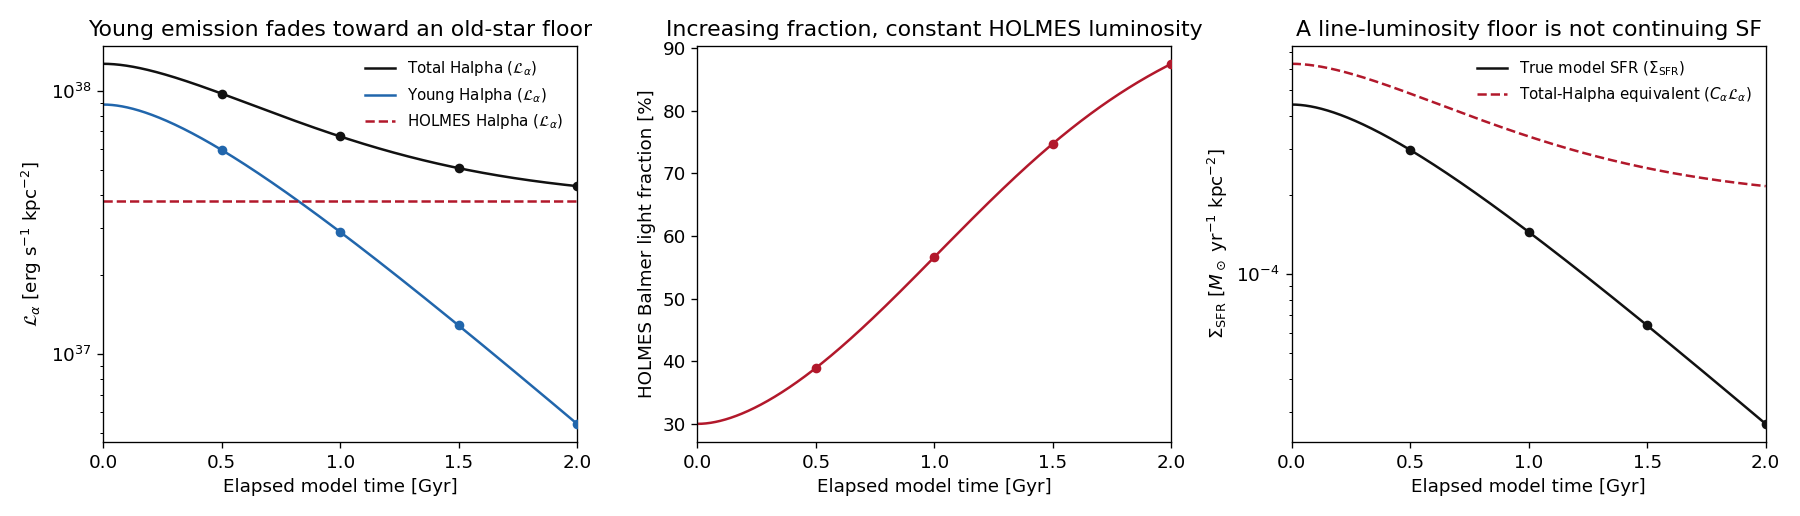

In [9]:
def emission_solution(sfr_fraction):
    fraction = np.asarray(sfr_fraction, dtype=float)
    young_ha = L_ALPHA_YOUNG_0*fraction
    holmes_ha = np.full_like(fraction, L_ALPHA_HOLMES)
    young = {'Halpha': young_ha, 'Hbeta': young_ha/BALMER_DECREMENT}
    holmes = {'Halpha': holmes_ha, 'Hbeta': holmes_ha/BALMER_DECREMENT}
    for ratio,line,balmer in [('N2','NII','Halpha'), ('S2','SII','Halpha'), ('O3','OIII','Hbeta')]:
        young[line] = YOUNG_RATIOS[ratio]*young[balmer]
        holmes[line] = HOLMES_RATIOS[ratio]*holmes[balmer]
    total = {line: young[line]+holmes[line] for line in young}
    weight = holmes_ha/total['Halpha']
    ratios = {'N2': total['NII']/total['Halpha'], 'S2': total['SII']/total['Halpha'],
              'O3': total['OIII']/total['Hbeta']}
    return {'young': young, 'HOLMES': holmes, 'total': total, 'weight': weight, 'ratios': ratios}

EMISSION = emission_solution(reference['F_SFR'])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for label, values, color, style in [
    ('Total Halpha', EMISSION['total']['Halpha'], '#111111', '-'),
    ('Young Halpha', EMISSION['young']['Halpha'], '#2166ac', '-'),
    ('HOLMES Halpha', EMISSION['HOLMES']['Halpha'], '#b2182b', '--')]:
    print_plot_initial(TIME_GYR, values, label+' ('+LINE_SYMBOLS['Halpha']+')', units='erg s^-1 kpc^-2')
    axes[0].plot(TIME_GYR, values, color=color, ls=style, label=label+' ('+LINE_SYMBOLS['Halpha']+')')
axes[0].set_yscale('log')
axes[0].set_ylabel(r'$\mathcal{L}_\alpha$ [erg s$^{-1}$ kpc$^{-2}$]')
axes[0].set_title('Young emission fades toward an old-star floor')
print_plot_initial(TIME_GYR, EMISSION['weight']*100, 'Curve in cell 16', units='%')
axes[1].plot(TIME_GYR, EMISSION['weight']*100, color='#b2182b')
axes[1].set_ylabel('HOLMES Balmer light fraction [%]')
axes[1].set_title('Increasing fraction, constant HOLMES luminosity')
print_plot_initial(TIME_GYR, reference['SFR'], r'True model SFR ($\Sigma_{\rm SFR}$)', units='Msun yr^-1 kpc^-2')
axes[2].plot(TIME_GYR, reference['SFR'], color='#111111', label=r'True model SFR ($\Sigma_{\rm SFR}$)')
print_plot_initial(TIME_GYR, C_ALPHA*EMISSION['total']['Halpha'], r'Total-Halpha equivalent ($C_\alpha\mathcal{L}_\alpha$)', units='Msun yr^-1 kpc^-2')
axes[2].plot(TIME_GYR, C_ALPHA*EMISSION['total']['Halpha'], '--', color='#b2182b',
             label=r'Total-Halpha equivalent ($C_\alpha\mathcal{L}_\alpha$)')
axes[2].set_yscale('log')
axes[2].set_ylabel(r'$\Sigma_{\rm SFR}$ [$M_\odot$ yr$^{-1}$ kpc$^{-2}$]')
axes[2].set_title('A line-luminosity floor is not continuing SF')
for ax in axes:
    ax.set_xlabel('Elapsed model time [Gyr]')
    format_time_axis(ax)
axes[0].legend(frameon=False, fontsize=9)
axes[2].legend(frameon=False, fontsize=9)
mark_time_checkpoints(axes[0], EMISSION['total']['Halpha'], '#111111')
mark_time_checkpoints(axes[0], EMISSION['young']['Halpha'], '#2166ac')
mark_time_checkpoints(axes[1], EMISSION['weight']*100, '#b2182b')
mark_time_checkpoints(axes[2], reference['SFR'], '#111111')
fig.tight_layout()
plt.show()

## Differential line fading and ratio growth

The first figure below is the **coupled gas prediction over 0--2 Gyr**. Each line is
normalized by its own initial total luminosity. Equal Balmer decrements make H$\alpha$
and H$\beta$ fade identically. Larger HOLMES forbidden-line ratios make those lines
fade more slowly, while all absolute luminosities decrease in this reference history.

The second figure extends the **same mixing equations** over $10^{-4}\leq F\leq1$.
This is a relation between remaining young emission and the line spectrum. Values beyond
the 2-Gyr endpoint are algebraic extrapolations, not additional elapsed-time predictions.
The marker shows how far the adopted gas model actually evolves by 2 Gyr. In particular,
a visually strong ratio rise can require much more SFR suppression than this gas model
produces in the plotted time interval.


Before plotting Halpha ($\mathcal{L}_\alpha$): first plotted x = 0; y = 1 [dimensionless]
Initial HI = 10, H2 = 0.882586 [Msun pc^-2]; SFR = 0.000441293 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 1.58866, net consumption (gamma_H2 Sigma_H2) = 1.58866 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1
Initial Halpha: young = 8.86131e+37, HOLMES = 3.7977e+37, model total = 1.2659e+38 [erg s^-1 kpc^-2]; HOLMES weight = 0.3; young ratios = {'N2': 0.1, 'S2': 0.06309573444801933, 'O3': 0.31622776601683794}; HOLMES ratios = {'N2': 1.7782794100389228, 'S2': 1.5848931924611136, 'O3': 3.1622776601683795}
Assumed log10 templates: young = {'N2': -1.0, 'S2': -1.2, 'O3': -0.5}; HOLMES = {'N2': 0.25, 'S2': 0.2, 'O3': 0.5}

Before plotting Hbeta ($\mathcal{L}_\beta$): first plotted x = 0; y = 1 [dimensionless]
Initial HI = 10, H2 = 0.882586 [Msun pc^-2]; SFR = 0.000441293 [Msun yr^

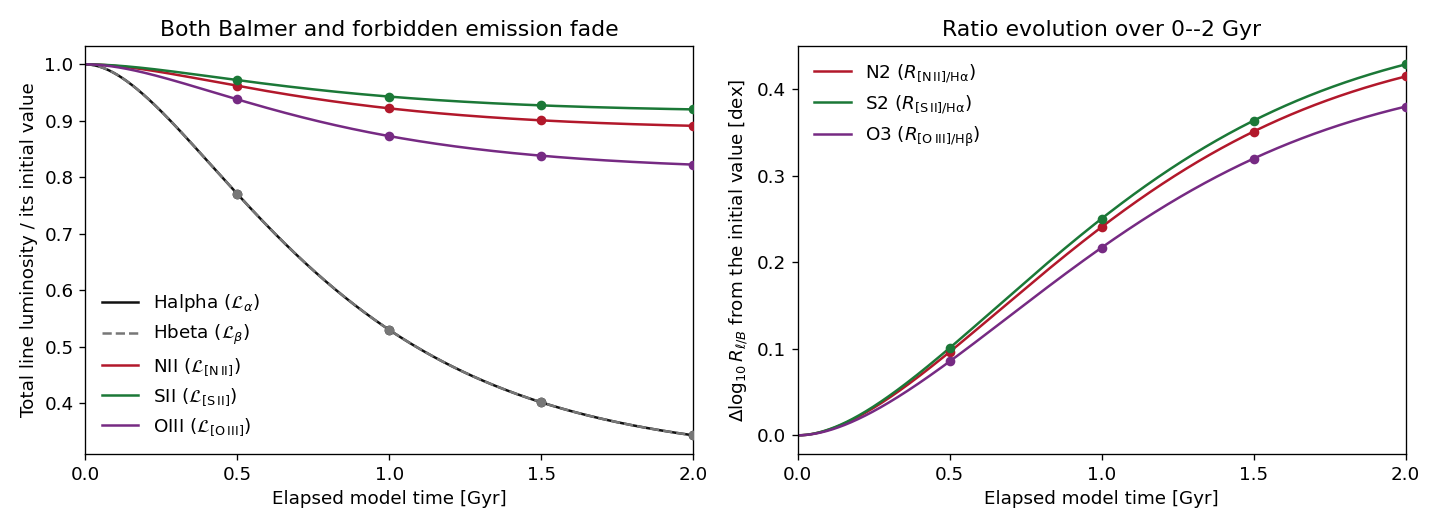

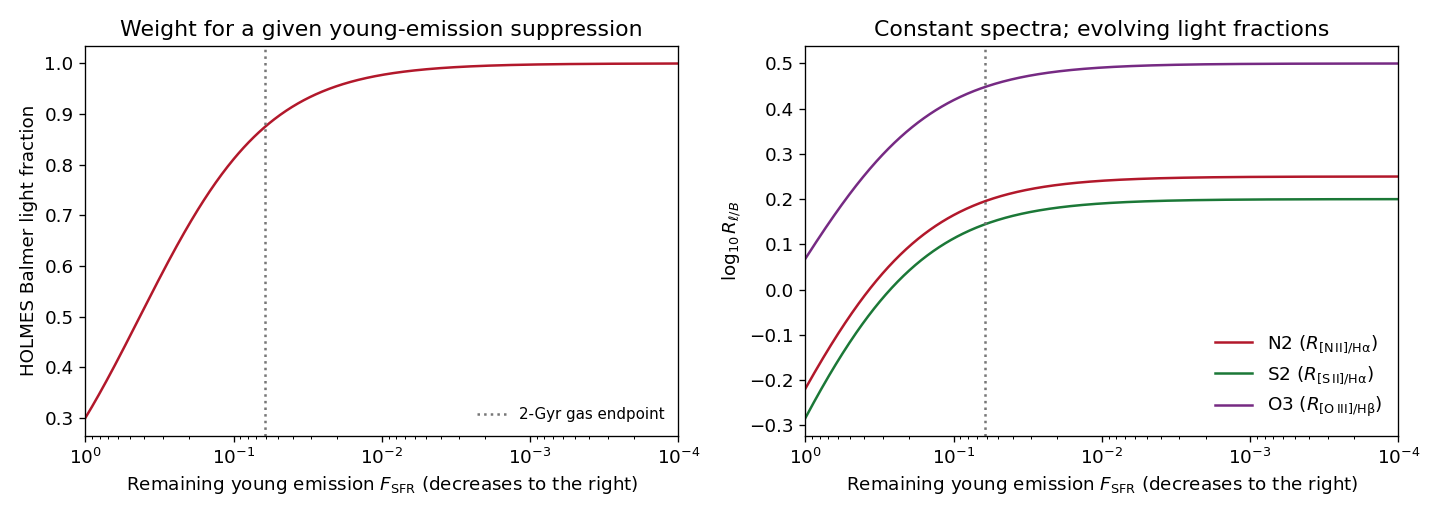

<IPython.core.display.Markdown object>

   time_Gyr  SFR_Msun_yr_kpc2  remaining_SFR  HOLMES_weight_percent  \
0       0.0          0.000441       1.000000              30.000000   
1       0.5          0.000297       0.672129              38.936236   
2       1.0          0.000145       0.327997              56.646744   
3       1.5          0.000064       0.144633              74.767639   
4       2.0          0.000027       0.061128              87.517244   

   Halpha_total_erg_s_kpc2  Halpha_young_erg_s_kpc2        N2        S2  \
0             1.265901e+38             8.861310e+37  0.603484  0.519635   
1             9.753651e+37             5.955946e+37  0.753459  0.655626   
2             6.704188e+37             2.906484e+37  1.050691  0.925144   
3             5.079342e+37             1.281638e+37  1.354810  1.200908   
4             4.339378e+37             5.416740e+36  1.568784  1.394931   

         O3  delta_log_N2_dex  delta_log_S2_dex  delta_log_O3_dex  
0  1.170043          0.000000          0.000000       

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for line,color in LINE_COLORS.items():
    series = EMISSION['total'][line]
    print_plot_initial(TIME_GYR, series/series[0], line+' ('+LINE_SYMBOLS[line]+')', units='dimensionless')
    axes[0].plot(TIME_GYR, series/series[0], color=color,
                 ls='--' if line == 'Hbeta' else '-', label=line+' ('+LINE_SYMBOLS[line]+')')
for ratio,color in [('N2','#b2182b'), ('S2','#1b7837'), ('O3','#762a83')]:
    print_plot_initial(TIME_GYR, np.log10(EMISSION['ratios'][ratio]/EMISSION['ratios'][ratio][0]), ratio+' ('+RATIO_SYMBOLS[ratio]+')', units='dex')
    axes[1].plot(TIME_GYR, np.log10(EMISSION['ratios'][ratio]/EMISSION['ratios'][ratio][0]), color=color, label=ratio+' ('+RATIO_SYMBOLS[ratio]+')')
axes[0].set(xlabel='Elapsed model time [Gyr]', ylabel='Total line luminosity / its initial value',
            title='Both Balmer and forbidden emission fade')
axes[1].set(xlabel='Elapsed model time [Gyr]', ylabel=r'$\Delta\log_{10} R_{\ell/B}$ from the initial value [dex]',
            title='Ratio evolution over 0--2 Gyr')
for ax in axes:
    ax.legend(frameon=False)
    format_time_axis(ax)
for line,color in LINE_COLORS.items():
    values = EMISSION['total'][line]
    mark_time_checkpoints(axes[0], values/values[0], color)
for ratio,color in [('N2','#b2182b'), ('S2','#1b7837'), ('O3','#762a83')]:
    values = EMISSION['ratios'][ratio]
    mark_time_checkpoints(axes[1], np.log10(values/values[0]), color)
fig.tight_layout()
plt.show()

FADE_GRID = np.geomspace(1.0, 1e-4, 701)
FADE_EMISSION = emission_solution(FADE_GRID)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
print_plot_initial(FADE_GRID, FADE_EMISSION['weight'], 'Curve in cell 18', units='dimensionless')
axes[0].plot(FADE_GRID, FADE_EMISSION['weight'], color='#b2182b')
axes[0].set(ylabel='HOLMES Balmer light fraction', title='Weight for a given young-emission suppression')
for ratio,color in [('N2','#b2182b'), ('S2','#1b7837'), ('O3','#762a83')]:
    print_plot_initial(FADE_GRID, np.log10(FADE_EMISSION['ratios'][ratio]), ratio+' ('+RATIO_SYMBOLS[ratio]+')', units='dex')
    axes[1].plot(FADE_GRID, np.log10(FADE_EMISSION['ratios'][ratio]), color=color, label=ratio+' ('+RATIO_SYMBOLS[ratio]+')')
axes[1].set(ylabel=r'$\log_{10} R_{\ell/B}$', title='Constant spectra; evolving light fractions')
axes[1].legend(frameon=False)
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlim(1, 1e-4)
    ax.axvline(reference['F_SFR'][-1], color='#777777', ls=':', label='2-Gyr gas endpoint')
    ax.set_xlabel(r'Remaining young emission $F_{\rm SFR}$ (decreases to the right)')
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

emission_rows = []
for time in np.r_[0.0, CHECKPOINT_TIMES]:
    gas = gas_solution(time)
    spectrum = emission_solution(gas['F_SFR'])
    emission_rows.append({
        'time_Gyr': time, 'SFR_Msun_yr_kpc2': float(gas['SFR']),
        'remaining_SFR': float(gas['F_SFR']), 'HOLMES_weight_percent': 100*float(spectrum['weight']),
        'Halpha_total_erg_s_kpc2': float(spectrum['total']['Halpha']),
        'Halpha_young_erg_s_kpc2': float(spectrum['young']['Halpha']),
        **{name: float(value) for name,value in spectrum['ratios'].items()},
        **{f'delta_log_{name}_dex': float(np.log10(value/EMISSION['ratios'][name][0]))
           for name,value in spectrum['ratios'].items()}})
EMISSION_SUMMARY = pd.DataFrame(emission_rows)
display(Markdown('**Reference predictions.** SFR has units Msun yr^-1 kpc^-2; Halpha surface luminosities have units erg s^-1 kpc^-2. N2, S2 and O3 are linear ratios; their changes are logarithmic dex.'))
with pd.option_context('display.max_columns', None):
    display(EMISSION_SUMMARY)


## BPT-plane prediction from the cell 18 line-ratio model

The solid black track is the coupled gas model over **0--2 Gyr**. Markers identify
**0.5, 1.0, 1.5, and 2.0 Gyr**, and the insets show the coupled-model trajectory.
The dashed grey continuation is the algebraic mixing curve down to $F=10^{-4}$;
it is not an additional prediction within 2 Gyr. Separate markers show the constant young
and HOLMES templates; the trajectory starts at the chosen mixture, not the pure-young point.
This figure shows model predictions only; it reuses `EMISSION`
and `FADE_EMISSION` from cell 18 without recalculating or fitting the ratios. Its
normalization uses the previously defined faint-NSF Composite initial state, with $w_0=0.30$
and $\eta=3$. The initial model point is marked explicitly.

Every BPT panel uses the standard demarcation relations for its plane. Define
$x_{\rm N2}=\log_{10}([\mathrm{N\,II}]/\mathrm H\alpha)$,
$x_{\rm S2}=\log_{10}([\mathrm{S\,II}]/\mathrm H\alpha)$, and
$y=\log_{10}([\mathrm{O\,III}]/\mathrm H\beta)$:

$$\begin{aligned}
y_{\rm Ke01,N2}&=\frac{0.61}{x_{\rm N2}-0.47}+1.19,\qquad x_{\rm N2}<0.47,\\
y_{\rm Ka03,N2}&=\frac{0.61}{x_{\rm N2}-0.05}+1.30,\qquad x_{\rm N2}<0.05,\\
y_{\rm Ke01,S2}&=\frac{0.72}{x_{\rm S2}-0.32}+1.30,\qquad x_{\rm S2}<0.32,\\
y_{\rm Ke06,S2}&=1.89x_{\rm S2}+0.76.
\end{aligned}$$

Ke01 is the maximum-starburst boundary in both planes
([Kewley et al. 2001, equations 5--6](https://arxiv.org/pdf/astro-ph/0106324));
Ka03 is the empirical SF boundary in the **N2 plane**
([Kauffmann et al. 2003, equation 1](https://arxiv.org/pdf/astro-ph/0304239));
Ke06 divides Seyfert/LINER-like excitation in the **S2 plane**, above Ke01
([Kewley et al. 2006, equation 10 and Figure 4](https://arxiv.org/pdf/astro-ph/0605681)).
We draw Ke06 from its intersection with Ke01 onwards. The helper below is called
for both main panels and both insets, and restricts hyperbolae to their left branches.
The insets use the same demarcations and show them wherever they cross the model range.
These are **demarcation curves**, distinct from the Balmer decrement Halpha/Hbeta = 2.86.
The curves label excitation regions; they do not by themselves identify the physical ionizing source.



Before plotting N2 BPT demarcation: first plotted x = -1.5; y = 0.880355 [log10 line ratio (dex)]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.

Before plotting N2 BPT demarcation: first plotted x = -1.5; y = 0.906452 [log10 line ratio (dex)]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.

Before plotting Mixing continuation: first plotted x = -0.219334; y = 0.0682017 [log10 line ratio (dex)]
Initial HI = 10, H2 = 0.882586 [Msun pc^-2]; SFR = 0.000441293 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 1.58866, net consumption (gamma_H2 Sigma_H2) = 1.58866 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1
Initial Halpha: young = 8.86131e+37, HOLMES = 3.7977e+37, model total = 1.2659e+38 [erg s^-1 kpc^-2]; HOLMES weight = 0.3; young ratios = {'N2': 0.1, 'S2': 0.06309573444801933, 'O3': 0.316227766016

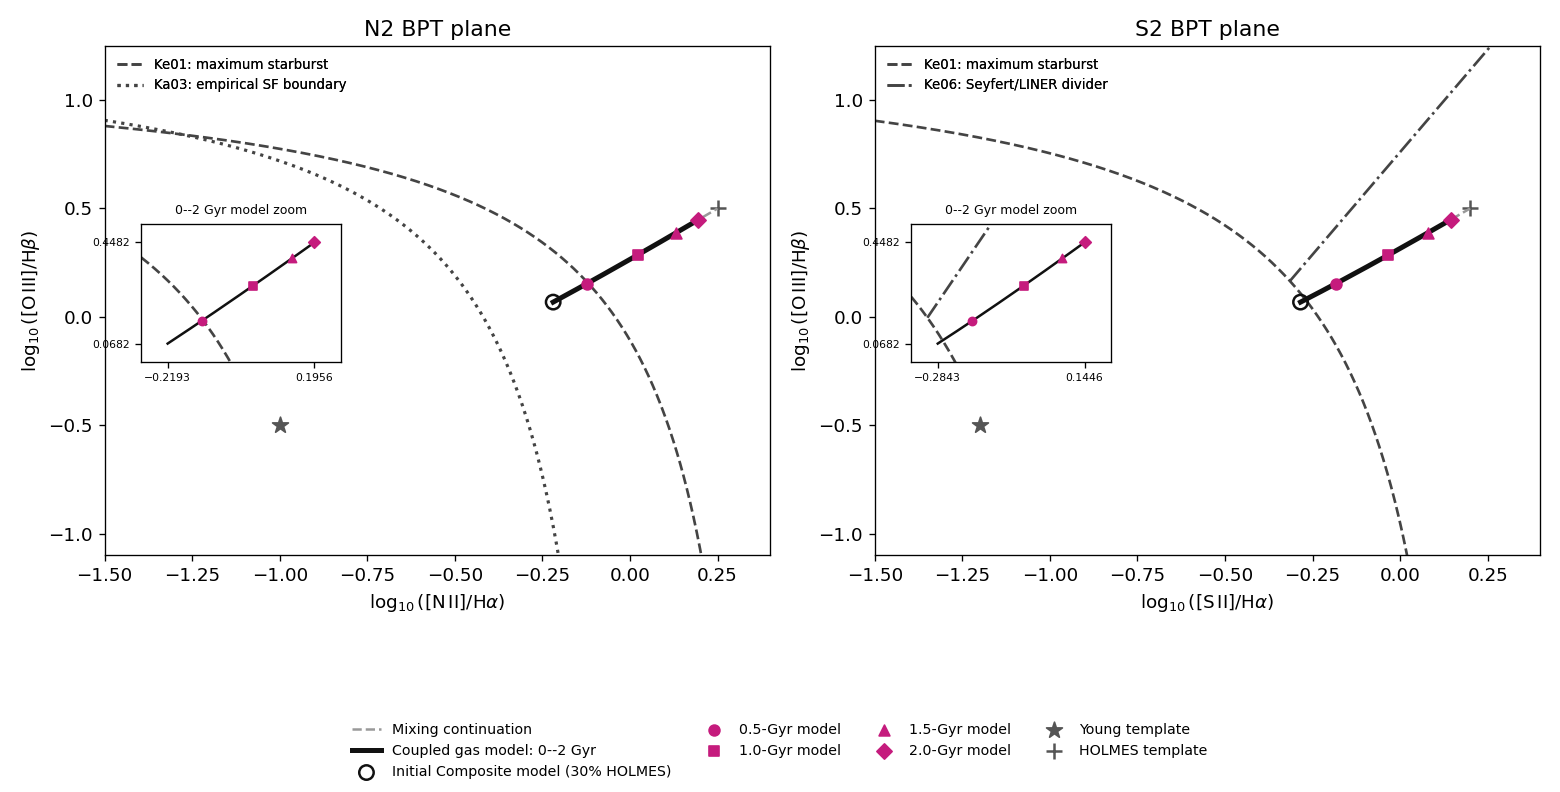

In [11]:
def plot_bpt_demarcations(ax, plane, xlimits, *, legend_labels=True):
    """Standard Ke01/Ka03/Ke06 relations; only the appropriate BPT plane."""
    label = lambda text: text if legend_labels else '_nolegend_'
    artists = []
    lo, hi = xlimits
    if plane == 'N2':
        x = np.linspace(lo, min(hi, 0.47-0.01), 800)
        print_plot_initial(x, 0.61/(x-0.47)+1.19, plane+' BPT demarcation', units='log10 line ratio (dex)', model=False)
        artists += ax.plot(x, 0.61/(x-0.47)+1.19, '--', color='#444444', lw=1.6,
                           label=label('Ke01: maximum starburst'), zorder=1)
        x = np.linspace(lo, min(hi, 0.05-0.01), 800)
        print_plot_initial(x, 0.61/(x-0.05)+1.30, plane+' BPT demarcation', units='log10 line ratio (dex)', model=False)
        artists += ax.plot(x, 0.61/(x-0.05)+1.30, ':', color='#444444', lw=1.9,
                           label=label('Ka03: empirical SF boundary'), zorder=1)
    elif plane == 'S2':
        x = np.linspace(lo, min(hi, 0.32-0.01), 800)
        print_plot_initial(x, 0.72/(x-0.32)+1.30, plane+' BPT demarcation', units='log10 line ratio (dex)', model=False)
        artists += ax.plot(x, 0.72/(x-0.32)+1.30, '--', color='#444444', lw=1.6,
                           label=label('Ke01: maximum starburst'), zorder=1)
        intersection = (159-np.sqrt(105081))/525
        if hi > intersection:
            x = np.linspace(max(lo, intersection), hi, 300)
            print_plot_initial(x, 1.89*x+0.76, plane+' BPT demarcation', units='log10 line ratio (dex)', model=False)
            artists += ax.plot(x, 1.89*x+0.76, '-.', color='#444444', lw=1.6,
                               label=label('Ke06: Seyfert/LINER divider'), zorder=1)
    else:
        raise ValueError(f'Unsupported BPT plane: {plane}')
    return artists

CHECKPOINT_SPECTRA = [emission_solution(gas_solution(time)['F_SFR']) for time in CHECKPOINT_TIMES]
def make_bpt_prediction_figure():
    """Plot only the EMISSION/FADE_EMISSION predictions already computed in cell 18."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 6.6))
    axes_audit = []
    for ax, xratio in zip(axes, ('N2','S2')):
        xlimits, ylimits = (-1.5, 0.4), (-1.1, 1.25)
        demarcations = plot_bpt_demarcations(ax, xratio, xlimits)
        curve_legend = ax.legend(handles=demarcations, loc='upper left', frameon=False, fontsize=8)
        ax.add_artist(curve_legend)
        print_plot_initial(np.log10(FADE_EMISSION['ratios'][xratio]), np.log10(FADE_EMISSION['ratios']['O3']), 'Mixing continuation', units='log10 line ratio (dex)')
        ax.plot(np.log10(FADE_EMISSION['ratios'][xratio]), np.log10(FADE_EMISSION['ratios']['O3']),
                '--', color='#999999', lw=1.5, label='Mixing continuation')
        print_plot_initial(np.log10(EMISSION['ratios'][xratio]), np.log10(EMISSION['ratios']['O3']), 'Coupled gas model: 0--2 Gyr', units='log10 line ratio (dex)')
        ax.plot(np.log10(EMISSION['ratios'][xratio]), np.log10(EMISSION['ratios']['O3']),
                color='#111111', lw=3, label='Coupled gas model: 0--2 Gyr')
        ax.scatter(np.log10(INITIAL_MODEL_RATIOS[xratio]), np.log10(INITIAL_MODEL_RATIOS['O3']),
                   marker='o', s=75, facecolors='none', edgecolors='#111111', lw=1.5,
                   zorder=6, label='Initial Composite model (30% HOLMES)')
        for time,marker,spectrum in zip(CHECKPOINT_TIMES, CHECKPOINT_MARKERS, CHECKPOINT_SPECTRA):
            ax.scatter(np.log10(spectrum['ratios'][xratio]), np.log10(spectrum['ratios']['O3']),
                       color='#c51b7d', marker=marker, s=42, zorder=5, label=f'{time:.1f}-Gyr model')
        for template, ratios, marker in [('Young template', YOUNG_RATIOS, '*'),
                                         ('HOLMES template', HOLMES_RATIOS, '+')]:
            ax.scatter(np.log10(ratios[xratio]), np.log10(ratios['O3']), marker=marker,
                       color='#555555', s=100, label=template)
        ax.set_xlim(xlimits)
        ax.set_ylim(ylimits)
        xlabel = (r'$\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$' if xratio == 'N2'
                  else r'$\log_{10}([\mathrm{S\,II}]/\mathrm{H}\alpha)$')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(r'$\log_{10}([\mathrm{O\,III}]/\mathrm{H}\beta)$')
        ax.set_title(xratio+' BPT plane')
        # Resolve the checkpoints while retaining actual BPT coordinates.
        zoom = ax.inset_axes([0.055, 0.38, 0.30, 0.27])
        model_x = np.log10(EMISSION['ratios'][xratio])
        model_y = np.log10(EMISSION['ratios']['O3'])
        pad_x, pad_y = 0.18*np.ptp(model_x), 0.18*np.ptp(model_y)
        zoom_limits = (model_x.min()-pad_x, model_x.max()+pad_x)
        plot_bpt_demarcations(zoom, xratio, zoom_limits, legend_labels=False)
        print_plot_initial(model_x, model_y, '0--2 Gyr BPT prediction zoom', units='log10 line ratio (dex)')
        zoom.plot(model_x, model_y, color='#111111', lw=1.5)
        for time,marker,spectrum in zip(CHECKPOINT_TIMES, CHECKPOINT_MARKERS, CHECKPOINT_SPECTRA):
            zoom.scatter(np.log10(spectrum['ratios'][xratio]), np.log10(spectrum['ratios']['O3']),
                         color='#c51b7d', marker=marker, s=24, zorder=5)
        zoom.set_xlim(zoom_limits)
        zoom.set_ylim(model_y.min()-pad_y, model_y.max()+pad_y)
        zoom.set_title('0--2 Gyr model zoom', fontsize=7.5)
        zoom.set_xticks([model_x.min(), model_x.max()])
        zoom.set_yticks([model_y.min(), model_y.max()])
        zoom.tick_params(labelsize=6.5)
        zoom.ticklabel_format(useOffset=False)
        axes_audit.append({'plane':xratio, 'main':ax, 'zoom':zoom,
                               'demarcation_labels':[line.get_label() for line in demarcations]})
    handles, labels = axes[1].get_legend_handles_labels()
    handles, labels = zip(*[(h,l) for h,l in zip(handles,labels) if not l.startswith(('Ke01','Ke06'))])
    fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, fontsize=8.5,
               bbox_to_anchor=(0.5, 0.0))
    fig.tight_layout(rect=(0, 0.20, 1, 1))
    return fig, axes, axes_audit

fig, axes, BPT_AXES_AUDIT = make_bpt_prediction_figure()
plt.show()


## Compare the BPT prediction with real MAUVE data

The following cell overlays the freshly measured MAUVE stage medians on the same
model predictions shown in cell 20. Filled circles denote SF and open squares NSF.
Bars show the marginal 16th--84th percentile galaxy scatter in each BPT coordinate,
not uncertainty on the median or a joint confidence region. The model has not been
fitted to these points; its 30% initial weight describes the stated fainter NSF-like
starting condition, whose Halpha scale is reported separately from the observed median. NSF is a selection category, not a pure HOLMES template;
the audit immediately after this comparison checks its membership and locations.



Before plotting N2 BPT demarcation: first plotted x = -1.5; y = 0.880355 [log10 line ratio (dex)]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.

Before plotting N2 BPT demarcation: first plotted x = -1.5; y = 0.906452 [log10 line ratio (dex)]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.

Before plotting Mixing continuation: first plotted x = -0.219334; y = 0.0682017 [log10 line ratio (dex)]
Initial HI = 10, H2 = 0.882586 [Msun pc^-2]; SFR = 0.000441293 [Msun yr^-1 kpc^-2]; molecular supply (Sigma_Phi) = 1.58866, net consumption (gamma_H2 Sigma_H2) = 1.58866 [Msun pc^-2 Gyr^-1]
Settings: tau_dep = 2, tau_conv = 6.29463 [Gyr]; R = 0.4, eta = 3; gamma_strip = 3 [Gyr^-1]; Sigma_star = 3.95401e+08 [Msun kpc^-2]; f_old = 1
Initial Halpha: young = 8.86131e+37, HOLMES = 3.7977e+37, model total = 1.2659e+38 [erg s^-1 kpc^-2]; HOLMES weight = 0.3; young ratios = {'N2': 0.1, 'S2': 0.06309573444801933, 'O3': 0.316227766016

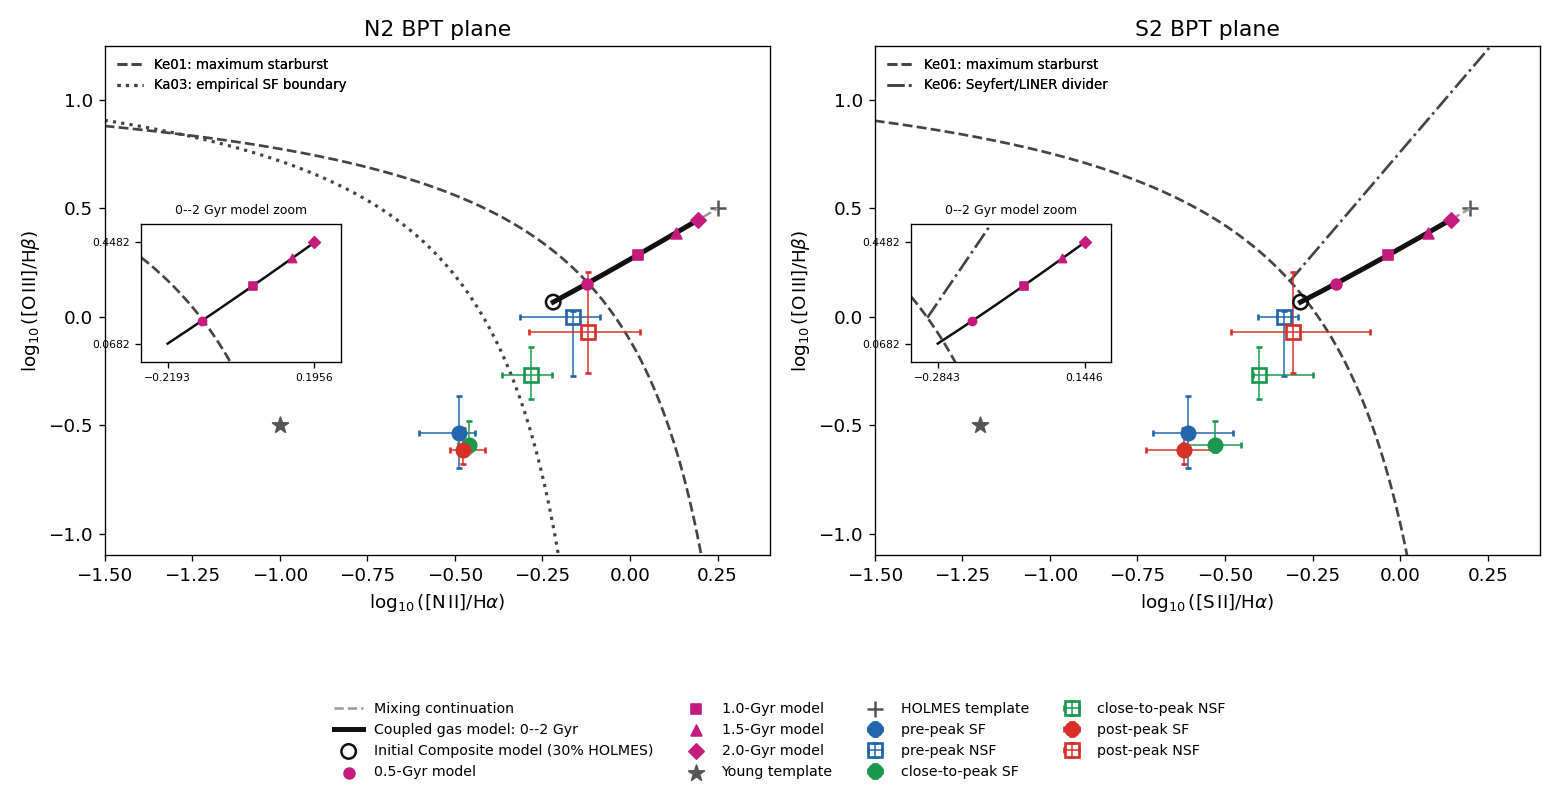

In [12]:
fig, axes, MAUVE_BPT_AXES_AUDIT = make_bpt_prediction_figure()
for ax, xratio in zip(axes, ('N2', 'S2')):
    for row in OBS_STAGE.itertuples(index=False):
        color = STAGE_COLORS[row.stage]
        xcentre, ycentre = np.log10(getattr(row,xratio)), np.log10(row.O3)
        xlo, xhi = getattr(row,xratio+'_log_p16'), getattr(row,xratio+'_log_p84')
        ylo, yhi = row.O3_log_p16, row.O3_log_p84
        ax.errorbar(xcentre, ycentre,
                    xerr=np.array([[xcentre-xlo], [xhi-xcentre]]),
                    yerr=np.array([[ycentre-ylo], [yhi-ycentre]]),
                    fmt='o' if row.category == 'SF' else 's', ms=8,
                    color=color, markerfacecolor=color if row.category == 'SF' else 'none',
                    markeredgewidth=1.6, elinewidth=0.9, capsize=2,
                    label=f'{row.stage} {row.category}')

# Add the real-data entries to this comparison figure's legend.
for legend in list(fig.legends):
    legend.remove()
handles, labels = axes[1].get_legend_handles_labels()
handles, labels = zip(*[(h,l) for h,l in zip(handles,labels) if not l.startswith(('Ke01','Ke06'))])
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False, fontsize=8.5,
           bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=(0, 0.20, 1, 1))
plt.show()


## Why can the observed NSF points lie below the BPT boundaries?

The selection in this notebook is exactly

$$\mathrm{SF}=\mathrm{usable}\cap\mathrm{finite\ HII\ SFR}
\cap\{\mathrm{EW}(\mathrm H\alpha)>6\ \mathring{\mathrm A}\}
\cap\{\sigma_{\mathrm H\alpha,\rm intrinsic}<45\ \mathrm{km\ s^{-1}}\},$$
$$\mathrm{NSF}=\mathrm{usable}\cap\mathrm{Balmer\ detected}\cap\neg\mathrm{SF}.$$

Consequently, low-EW or broad-line regions can be NSF with HII-like BPT ratios. Failure
of HII eligibility can also reflect the other BPT plane or an uncertainty-sensitive
classification. It does not by itself establish a HOLMES-dominated source. Failing an EW or dispersion
cut also does not prove that current star formation is absent.

In N2, points between Ka03 and Ke01 are Composite-like even though they lie below
Ke01. Ke06 is a Seyfert/LINER divider above the S2 Ke01 boundary, not an additional
HII/non-HII boundary. The pixel tests below use the appropriate SF boundary in
each plane; the plotted NSF medians are checked independently.

We check **the actual maps**, using the same mass window, SNR cut, common corrected-line
support, and eligible products as the plotted NSF stage points. The table partitions
NSF by its first failed SF gate (HII map, then EW, then dispersion). The separate BPT
diagnostic evaluates each pixel's central corrected ratios below Ka03/Ke01 in N2 and
below Ke01 in S2, and reports the stored confidence-sensitive class maps.

The live [`SFR+Z.py`](SFR+Z.py) source distinguishes these two classification products:
`NII_BPT`/`SII_BPT` assign positive codes only when the central and four displaced
$\pm1\sigma$ positions have the **same exact** class. In contrast, the HII-SFR map
with `BPTMODE='both'` uses central N2 HII membership with displaced points allowed in
the combined HII+Composite envelope, together with displaced S2 HII membership
(source lines 3237--3272, 3477, 3500--3554, and 3600--3622). We therefore use finite
HII SFR for the original gate; we do **not** replace it with two positive HII class codes.
Stored codes are N2: 1 HII, 2 Composite, 3 AGN-like; S2: 1 HII, 2 LINER-like, 3 Seyfert-like;
0 is unclassified and -1 is unknown/non-detected. These names describe excitation classes.

The plotted stage ratio is now a median of per-product median corrected pixel ratios:

$$R_{\ell/B}^{\rm stage}
=\operatorname{median}_g\left[\operatorname{median}_{p\in g}
\left(F_{\ell,p}/F_{B,p}\right)\right].$$

It is not a ratio of stage-summary luminosities. The BPT bars show marginal 16th--84th
percentile scatter of the same product summaries along each axis, not a joint confidence
region. A nonlinear boundary does not assign the median point the class of every constituent
pixel. We test the actual median coordinates directly.

First-failed gates partition the pixels and Halpha luminosity within each product. Physical
Halpha shares are ratios of summed pixel luminosities. We then report median per-product
shares and fractions, with 16th--84th percentile product scatter. Component-wise medians need
not sum to unity and are therefore plotted separately, without stacking or renormalization.
The full per-product diagnostic remains `NSF_DIAGNOSTICS_BY_GALAXY` for inspection.



Before plotting HII SFR unavailable: first plotted x = -0.15; y = 89.816 [%]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.

Before plotting EW fails after HII gate: first plotted x = 0; y = 0.550173 [%]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.

Before plotting Dispersion fails after HII/EW gates: first plotted x = 0.15; y = 9.68685 [%]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.

Before plotting central N2 HII-like: first plotted x = -0.15; y = 3.5033 [%]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.

Before plotting central S2 HII-like: first plotted x = 0; y = 76.3075 [%]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.

Before plotting central HII-like in both planes: first plotted x = 0.15; y = 3.5033 [%]
Observed diagnostic or boundary coordinates; no gas initial condition is assigned.


<IPython.core.display.Markdown object>

           stage    log_N2    log_S2    log_O3  N2_stage_below_SF_boundaries  \
0       pre-peak -0.163818 -0.331787  0.001177                         False   
1  close-to-peak -0.283151 -0.401631 -0.267732                         False   
2      post-peak -0.121320 -0.306995 -0.070027                         False   

   S2_stage_below_Ke01  O3_minus_Ka03_N2_dex  O3_minus_Ke01_S2_dex  
0                 True              1.554074             -0.194168  
1                 True              0.263268             -0.569992  
2                 True              2.190558             -0.221693  

            stage                  kind  \
0       post-peak  first failed SF gate   
1       post-peak  first failed SF gate   
2       post-peak  first failed SF gate   
3       post-peak  first failed SF gate   
4       post-peak  first failed SF gate   
5       post-peak  first failed SF gate   
6       post-peak  first failed SF gate   
7       post-peak    BPT location/class   
8       post-peak    BPT location/class   
9       post-peak    BPT location/class   
10      post-peak    BPT location/class   
11       pre-peak  first failed SF gate   
12       pre-peak  first failed SF gate   
13       pre-peak  first failed SF gate   
14       pre-peak  first failed SF gate   
15       pre-peak  first failed SF gate   
16       pre-peak  first failed SF gate   
17       pre-peak  first failed SF gate   
18       pre-peak    BPT location/class   
19       pre-peak    BPT location/class   
20       pre-peak    BPT location/class   
21       pre-peak    BPT location/class   
22  close-t

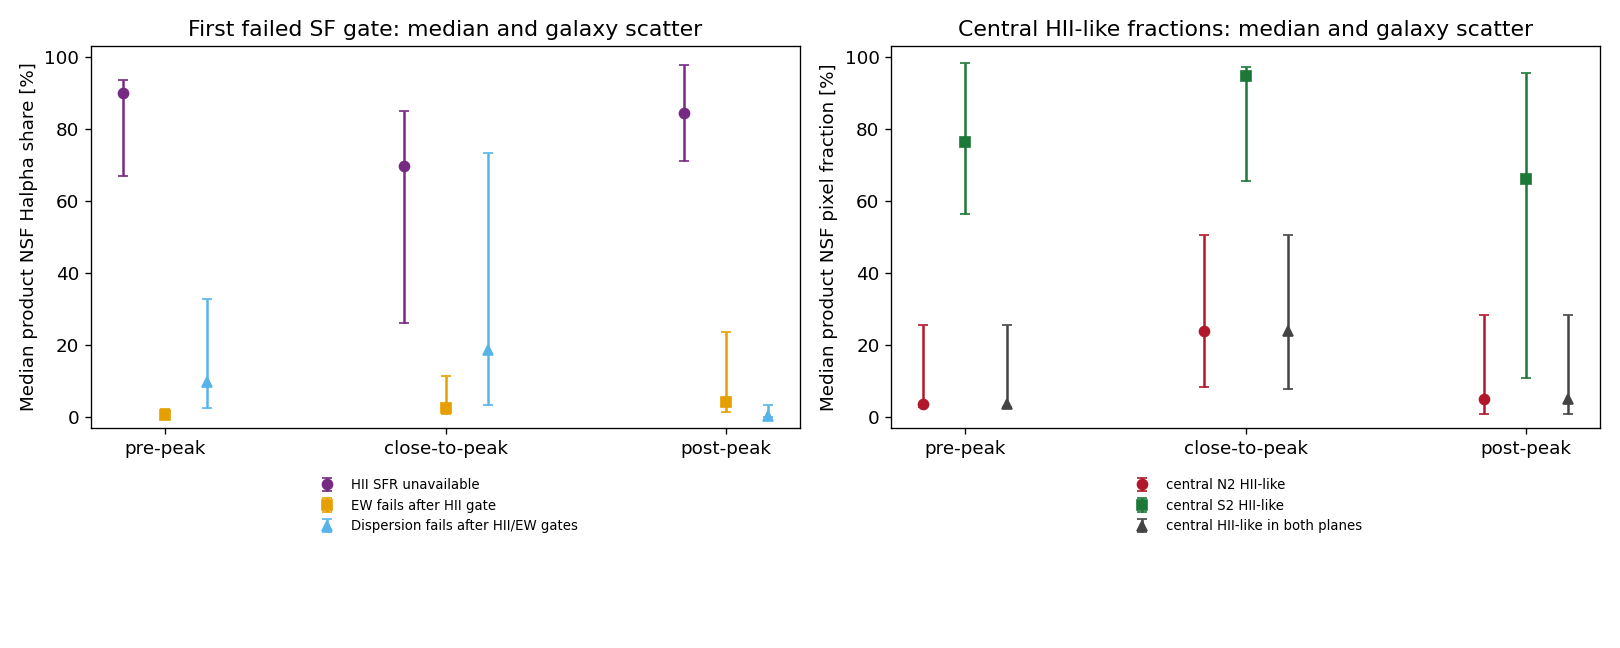

<IPython.core.display.Markdown object>

In [13]:
def fraction_scatter(values):
    lo, centre, hi = np.percentile(np.asarray(values, dtype=float), [16, 50, 84])
    return float(centre), float(lo), float(hi)

diagnostic_stage_rows = []
eligible_diagnostics = NSF_DIAGNOSTICS_BY_GALAXY.loc[NSF_DIAGNOSTICS_BY_GALAXY.eligible]
for (stage,kind,selection), group in eligible_diagnostics.groupby(['stage','kind','selection'], sort=False):
    expected = OBS_STAGE.loc[(OBS_STAGE.stage == stage) & (OBS_STAGE.category == 'NSF')].iloc[0]
    assert set(group.GALID) == set(expected.GALIDs.split(', '))
    pixel, pixel_lo, pixel_hi = fraction_scatter(group.pixel_fraction)
    light, light_lo, light_hi = fraction_scatter(group.Halpha_fraction)
    diagnostic_stage_rows.append({
        'stage': stage, 'kind': kind, 'selection': selection, 'N_products': len(group),
        'N_selected_pixels': int(group.N_selected.sum()),
        'median_product_pixel_fraction': pixel, 'pixel_p16': pixel_lo, 'pixel_p84': pixel_hi,
        'median_product_Halpha_fraction': light, 'Halpha_p16': light_lo, 'Halpha_p84': light_hi})
NSF_DIAGNOSTICS_STAGE = pd.DataFrame(diagnostic_stage_rows)
NSF_STAGE_LOCATIONS = []
for row in OBS_STAGE.loc[OBS_STAGE.category == 'NSF'].itertuples(index=False):
    n2_hii, s2_hii = central_hii_masks(row.N2, row.S2, row.O3)
    x_n2, x_s2, y = np.log10(row.N2), np.log10(row.S2), np.log10(row.O3)
    NSF_STAGE_LOCATIONS.append({
        'stage': row.stage, 'log_N2': x_n2, 'log_S2': x_s2, 'log_O3': y,
        'N2_stage_below_SF_boundaries': bool(n2_hii),
        'S2_stage_below_Ke01': bool(s2_hii),
        'O3_minus_Ka03_N2_dex': y-(0.61/(x_n2-0.05)+1.30),
        'O3_minus_Ke01_S2_dex': y-(0.72/(x_s2-0.32)+1.30)})
NSF_STAGE_LOCATIONS = pd.DataFrame(NSF_STAGE_LOCATIONS)
display(Markdown('**Direct check of the plotted NSF stage median coordinates.** Negative offsets lie below the indicated boundary.'))
with pd.option_context('display.max_columns', None, 'display.max_colwidth', 85, 'display.max_rows', None):
    display(NSF_STAGE_LOCATIONS)
    display(NSF_DIAGNOSTICS_STAGE)

gate_groups = [NSF_GATE_LABELS[:3], NSF_GATE_LABELS[3:5], NSF_GATE_LABELS[5:]]
gate_names = ('HII SFR unavailable','EW fails after HII gate','Dispersion fails after HII/EW gates')
gate_summary = []
for stage in STAGES:
    for labels,label in zip(gate_groups, gate_names):
        # Combine gates within each product before summarizing across products.
        product_shares = eligible_diagnostics.loc[(eligible_diagnostics.stage == stage)
            & eligible_diagnostics.selection.isin(labels)].groupby('GALID').Halpha_fraction.sum()
        centre,lo,hi = fraction_scatter(product_shares)
        gate_summary.append({'stage':stage, 'gate':label, 'median':centre, 'p16':lo, 'p84':hi})
NSF_GATE_STAGE = pd.DataFrame(gate_summary)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
stage_x = np.arange(len(STAGES))
for offset,label,color,marker in zip((-0.15,0,0.15), gate_names,
        ('#762a83','#e69f00','#56b4e9'), ('o','s','^')):
    rows = NSF_GATE_STAGE.loc[NSF_GATE_STAGE.gate == label].set_index('stage').loc[list(STAGES)]
    values = 100*rows['median'].to_numpy()
    errors = 100*np.array([rows['median']-rows.p16, rows.p84-rows['median']])
    print_plot_initial(stage_x+offset, values, label, units='%', model=False)
    axes[0].errorbar(stage_x+offset, values, yerr=errors, fmt=marker, color=color, capsize=3, label=label)
axes[0].set(ylabel='Median product NSF Halpha share [%]', ylim=(-3,103),
            title='First failed SF gate: median and galaxy scatter')
for offset,label,color,marker in zip((-0.15,0,0.15), NSF_CENTRAL_LABELS[:3],
        ('#b2182b','#1b7837','#444444'), ('o','s','^')):
    rows = NSF_DIAGNOSTICS_STAGE.loc[NSF_DIAGNOSTICS_STAGE.selection == label].set_index('stage').loc[list(STAGES)]
    values = 100*rows.median_product_pixel_fraction.to_numpy()
    errors = 100*np.array([rows.median_product_pixel_fraction-rows.pixel_p16,
                           rows.pixel_p84-rows.median_product_pixel_fraction])
    print_plot_initial(stage_x+offset, values, label, units='%', model=False)
    axes[1].errorbar(stage_x+offset, values, yerr=errors, fmt=marker, color=color, capsize=3, label=label)
axes[1].set(ylabel='Median product NSF pixel fraction [%]', ylim=(-3,103),
            title='Central HII-like fractions: median and galaxy scatter')
for ax in axes:
    ax.set_xticks(stage_x, STAGES)
    ax.legend(frameon=False, fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-0.10))
fig.tight_layout(rect=(0,0.12,1,1))
plt.show()

lines = []
for stage in STAGES:
    gates = NSF_GATE_STAGE.loc[NSF_GATE_STAGE.stage == stage].set_index('gate')
    group = NSF_DIAGNOSTICS_STAGE.loc[NSF_DIAGNOSTICS_STAGE.stage == stage].set_index('selection')
    ew_share = gates.loc[gate_names[1], 'median']
    sigma_share = gates.loc[gate_names[2], 'median']
    n2_fraction = group.loc[NSF_CENTRAL_LABELS[0], 'median_product_pixel_fraction']
    s2_fraction = group.loc[NSF_CENTRAL_LABELS[1], 'median_product_pixel_fraction']
    lines.append(f'- **{stage}:** median per-product NSF Halpha shares are {100*ew_share:.1f}% '
                 f'for the EW-failure branch and {100*sigma_share:.1f}% for the dispersion-failure branch. '
                 f'Median central HII-like pixel fractions are {100*n2_fraction:.1f}% (N2) '
                 f'and {100*s2_fraction:.1f}% (S2).')
display(Markdown('### What the live NSF audit establishes\n\n'+'\n'.join(lines)+
    '\n\nBars show the 16th--84th percentile scatter across products, not uncertainty on the median. '
    'Component-wise medians do not generally sum to 100%, so the gate medians are not stacked. '
    'A below-curve NSF median is compatible with the category definition. Neither the whole NSF '
    'sample nor its median square can be interpreted as a pure HOLMES template. The model remains '
    'a mechanism illustration, not a fit to this heterogeneous category.'))


## Read the prediction and retain the provenance

The following cell summarizes the actual values computed in this run. It also makes a few
short consistency checks: initial equality, the spatial difference identity, positive
gas columns, luminosity-weighted mixing, initial normalization, and the reference trends.
These establish that the numerical implementation follows the simple derivation.
They do not verify that the assumed timescales, absorption, or intrinsic HOLMES spectrum
describe every MAUVE region.

The old-star normalization assumes all measured stellar mass is old and all ionizing
photons are absorbed. Smaller old fractions or absorption fractions lower the floor.
Keeping the floor constant presumes retained absorbing gas and an old population. Ratios
are held constant as requested; harder source spectra alone do not universally fix the
ordering of every observed line ratio. Stage/category selection and six-line detection
also affect which regions enter the observational reference.

In [14]:
# Temporal initial-condition response, independently of any spatial factors.
for case,initial_h2 in TEMPORAL_INITIAL_H2.items():
    values = TEMPORAL_GAS[case]
    assert np.isclose(values['H2'][0], initial_h2)
    np.testing.assert_allclose(values['H2']/initial_h2, values['F_SFR'], rtol=1e-12)
    np.testing.assert_allclose(values['SFR']/(initial_h2/TAU_DEP*1e-3), values['F_SFR'], rtol=1e-12)
    if case == 'Monotonic decline':
        assert np.all(np.diff(values['H2']) < 0)
    else:
        peak_state = gas_solution(temporal_peak, sigma_h2_0=initial_h2)
        np.testing.assert_allclose(peak_state['supply'], GAMMA_H2*peak_state['H2'], rtol=1e-12)
        for time,sign in [(temporal_peak*0.5,1), (temporal_peak*1.5,-1)]:
            state = gas_solution(time, sigma_h2_0=initial_h2)
            assert sign*(state['supply']-GAMMA_H2*state['H2']) > 0
        assert peak_state['F_SFR'] > 1 and values['F_SFR'][-1] < 1
assert set(TEMPORAL_CHECKPOINTS.time_Gyr) == set(CHECKPOINT_TIMES)
# Spatial sign/identity applies to either reference history, without a peak condition.
for case,initial_h2 in TEMPORAL_INITIAL_H2.items():
    simultaneous = SPATIAL_GAS[case]['reference']
    for region,c in ATOMIC_FACTORS.items():
        values = SPATIAL_GAS[case][region]
        assert np.isclose(values['H2'][0], initial_h2)
        assert np.all(values['HI'] > 0) and np.all(values['H2'] > 0)
        np.testing.assert_allclose(values['H2']-simultaneous['H2'],
                                  (c-1)*simultaneous['supplied_H2'], rtol=1e-10, atol=1e-12)
        if case == 'Monotonic decline':
            assert np.all(np.diff(values['SFR']) < 0)
        else:
            assert values['SFR'][1] > values['SFR'][0]
    assert np.all(SPATIAL_GAS[case]['leading']['SFR'][1:] > simultaneous['SFR'][1:])
    assert np.all(SPATIAL_GAS[case]['trailing']['SFR'][1:] < simultaneous['SFR'][1:])
assert np.all(np.diff(reference['SFR']) < 0)
assert np.all(np.diff(EMISSION['weight']) > 0)
np.testing.assert_allclose(EMISSION['total']['Halpha'][0], L_ALPHA_MODEL_0, rtol=1e-12)
for name, values in EMISSION['ratios'].items():
    np.testing.assert_allclose(values, YOUNG_RATIOS[name]+(
        HOLMES_RATIOS[name]-YOUNG_RATIOS[name])*EMISSION['weight'], rtol=1e-12)
    np.testing.assert_allclose(values[0], INITIAL_MODEL_RATIOS[name], rtol=1e-12)
    assert np.all(np.diff(values) > 0)
for values in EMISSION['total'].values():
    assert np.all(np.diff(values) < 0)
half_weight_fraction = L_ALPHA_HOLMES/L_ALPHA_YOUNG_0
ratio_changes = {name: np.log10(values[-1]/values[0]) for name,values in EMISSION['ratios'].items()}
nsf_pre = OBS_STAGE.loc[(OBS_STAGE.stage == 'pre-peak') & (OBS_STAGE.category == 'NSF')].iloc[0]
nsf_post = OBS_STAGE.loc[(OBS_STAGE.stage == 'post-peak') & (OBS_STAGE.category == 'NSF')].iloc[0]
observed_nsf_changes = {name: np.log10(float(nsf_post[name])/float(nsf_pre[name])) for name in HOLMES_RATIOS}
display(pd.DataFrame({'coupled model: 2-Gyr minus initial, dex': ratio_changes,
                      'observed NSF: post-peak minus pre-peak, dex': observed_nsf_changes}))
text = f"""### Results of this execution

- The pre-peak NSF comparison uses **{int(observed_reference.N_galaxies)} supported products**, using medians of per-product median pixel values. Its measured Halpha scale is **{L_ALPHA_OBS_0:.4e} erg s^-1 kpc^-2** and stellar column is **{SIGMA_STAR:.4e} Msun kpc^-2**.
- The assumed feedback loading is **eta = {ETA:g}**, and the initial HOLMES fraction is **{100*W_HOLMES_0:.1f}%**. The initial N2 BPT point is **({initial_n2:.4f}, {initial_o3:.4f})**, between Ka03 and Ke01. Both spectra now use the explicit user-selected log10 templates, not SF-derived ratios.
- Keeping the old-star photon budget fixed gives illustrative initial total Halpha **{L_ALPHA_MODEL_0:.4e} erg s^-1 kpc^-2**, **{L_ALPHA_MODEL_0/L_ALPHA_OBS_0:.4f}** times the observed NSF median. The photon-budget HOLMES fraction at that observed median would instead be **{100*W_HOLMES_OBS_SCALE:.3f}%**. The 30% start represents a fainter NSF-like region, not a fit to the observed stage median.
- Initial true model SFR is **{SIGMA_SFR_0:.5f} Msun yr^-1 kpc^-2**. The derived initial H2 column is **{SIGMA_H2_0:.3f} Msun pc^-2**, and the derived conversion time is **{TAU_CONV:.4f} Gyr**.
- The **initially rising reference history**, with no spatial perturbation, reaches its temporal maximum at **{temporal_peak*1000:.2f} Myr**, **{100*(temporal_peak_state["F_SFR"]-1):.3f}%** above its own initial H2/SFR. The alternative initial condition decreases monotonically.
- Applying the same leading/reference/trailing HI factors to **each** history gives positive/zero/negative spatial offsets. In the monotonic case, even the leading position decreases throughout while remaining above its simultaneous reference. The temporal peak and spatial excess are different comparisons.
- By **2 Gyr**, the reference SFR retains **{reference['F_SFR'][-1]:.4f}** of its initial value. The HOLMES light fraction rises from **{100*W_HOLMES_0:.3f}%** to **{100*EMISSION['weight'][-1]:.3f}%**. The predicted logarithmic changes are N2 **{ratio_changes['N2']:+.4f} dex**, S2 **{ratio_changes['S2']:+.4f} dex**, and O3 **{ratio_changes['O3']:+.4f} dex**.
- A 50% HOLMES Balmer weight requires a remaining young-emission fraction **F = {half_weight_fraction:.5f}** for this normalization. Compare this with the actual 2-Gyr gas endpoint above; the algebraic mixing continuation does not establish that such deep fading is reached on a cluster-crossing timescale.
- Absolute Balmer and forbidden-line emission both fade in the reference calculation, while the ratios increase because their constant HOLMES contributions are relatively larger for the forbidden lines. **This demonstrates the mechanism; its observed amplitude remains a separate constraint.**
- The fresh NSF post-minus-pre contrasts in this mass interval are N2 **{observed_nsf_changes['N2']:+.4f} dex**, S2 **{observed_nsf_changes['S2']:+.4f} dex**, and O3 **{observed_nsf_changes['O3']:+.4f} dex**. Stage ordering is read from the median reference table above. These different regions and stage samples cannot be assigned the model's 0--2 Gyr interval; the adopted simple baseline does not quantitatively reproduce all of these descriptive contrasts.

Measured summaries are recomputed from live inputs; model quantities also depend on the stated eta and illustrative initial fraction. No prior report's numerical anchors or stored notebook outputs are imported. Short model consistency checks passed.
"""
display(Markdown(text))
PROVENANCE = pd.DataFrame(INPUT_PROVENANCE)
display(PROVENANCE)
assert np.isclose(TIME_GYR[-1], 2.0)
assert np.array_equal(EMISSION_SUMMARY.time_Gyr.to_numpy(), np.r_[0.0, CHECKPOINT_TIMES])
assert set(SPATIAL_CHECKPOINTS.time_Gyr) == set(CHECKPOINT_TIMES)
for audited in BPT_AXES_AUDIT + MAUVE_BPT_AXES_AUDIT:
    labels = audited['demarcation_labels']
    assert any(label.startswith('Ke01') for label in labels)
    assert any(label.startswith('Ka03' if audited['plane']=='N2' else 'Ke06') for label in labels)
assert np.isclose(ETA, 3.0)
assert INITIAL_MODEL_IS_COMPOSITE
assert np.isclose(EMISSION['weight'][0], INITIAL_HOLMES_FRACTION)
np.testing.assert_allclose(L_ALPHA_HOLMES, EPSILON_ALPHA*Q_H_HOLMES*F_OLD*SIGMA_STAR)
for name in ('N2','S2','O3'):
    np.testing.assert_allclose(np.log10(YOUNG_RATIOS[name]), {'N2':-1.0, 'S2':-1.2, 'O3':-0.5}[name], atol=1e-12)
    np.testing.assert_allclose(np.log10(HOLMES_RATIOS[name]), {'N2':0.25, 'S2':0.20, 'O3':0.5}[name], atol=1e-12)
assert np.all(EMISSION['ratios']['S2'] < EMISSION['ratios']['N2'])
assert not np.allclose(EMISSION['ratios']['N2']/EMISSION['ratios']['N2'][0],
                       EMISSION['ratios']['S2']/EMISSION['ratios']['S2'][0])
print('USER_SELECTED_LOG_TEMPLATES_OK')
print('NSF_COMPOSITE_INITIAL_STATE_AND_ETA3_OK')
print('NOTEBOOK_SIMPLE_MODEL_OK')
# Exclusive gate fractions must sum to unity per product, not after taking medians.
for galid,group in eligible_diagnostics.loc[
        eligible_diagnostics.kind == 'first failed SF gate'].groupby('GALID'):
    np.testing.assert_allclose(group.pixel_fraction.sum(), 1.0, rtol=1e-12)
    np.testing.assert_allclose(group.Halpha_fraction.sum(), 1.0, rtol=1e-12)
for row in OBS_STAGE.itertuples(index=False):
    group = OBS_BY_GALAXY.loc[(OBS_BY_GALAXY.stage == row.stage)
        & (OBS_BY_GALAXY.category == row.category) & OBS_BY_GALAXY.eligible]
    for key in ('Halpha','N2','S2','O3'):
        np.testing.assert_allclose(getattr(row,key), np.median(group[key]), rtol=1e-12)
        assert getattr(row,key+'_log_p16') <= np.log10(getattr(row,key)) <= getattr(row,key+'_log_p84')
print('MEDIAN_ESTIMATORS_AND_SCATTER_OK')
print('NSF_SELECTION_TEMPORAL_RESPONSE_AND_SPATIAL_CONTRAST_OK')


USER_SELECTED_LOG_TEMPLATES_OK
NSF_COMPOSITE_INITIAL_STATE_AND_ETA3_OK
NOTEBOOK_SIMPLE_MODEL_OK
MEDIAN_ESTIMATORS_AND_SCATTER_OK
NSF_SELECTION_TEMPORAL_RESPONSE_AND_SPATIAL_CONTRAST_OK


    coupled model: 2-Gyr minus initial, dex  observed NSF: post-peak minus pre-peak, dex
N2                                 0.414897                                     0.042498
S2                                 0.428854                                     0.024792
O3                                 0.380043                                    -0.071204

<IPython.core.display.Markdown object>

                                                  path  ...                                               HDUs
0    /Users/Igniz/Desktop/ICRAR/MAUVE/20261003 The ...  ...                                                   
1    /Users/Igniz/Desktop/ICRAR/further/mauve_maste...  ...                                                   
2    /Users/Igniz/Desktop/ICRAR/further/MAUVE_effec...  ...                                                   
3    /Users/Igniz/Desktop/ICRAR/further/20260930_ch...  ...                                                   
4          /Users/Igniz/Desktop/ICRAR/further/SFR+Z.py  ...                                                   
..                                                 ...  ...                                                ...
130  /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...  ...                            LOGMASS_SURFACE_DENSITY
131  /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...  ...  BIN_ID, LOGSFR_SURFACE_DENSITY, LOGSFR_SURFACE...
1

## Source references

The gas derivation, photon normalization, fixed intrinsic spectra and equal Balmer
decrements are taken from the **user-simplified October 3 report**, equations (1)--(40),
whose current fingerprint is printed above. This notebook evaluates that version and
does not import the later discussion or numerical machinery of older reports.

- [Huang et al. (2026)](https://doi.org/10.1093/mnras/stag1019): resolved regulator notation for molecular supply and SFR.
- [Leroy et al. (2013)](https://doi.org/10.1088/0004-6256/146/2/19): empirical context for a linear molecular star-formation law; the specific 2-Gyr value here is an adopted example.
- [Kennicutt & Evans (2012)](https://doi.org/10.1146/annurev-astro-081811-125610): young-star emission and recent-SFR calibration context. The numerical Chabrier coefficient is the one adopted in the report and local MAUVE pipeline.
- [Belfiore et al. (2022)](https://doi.org/10.1051/0004-6361/202141859): adopted HOLMES photon normalization, as specified by the report.
- [Cid Fernandes et al. (2011)](https://doi.org/10.1111/j.1365-2966.2011.18244.x) and [Hummer & Storey (1987)](https://doi.org/10.1093/mnras/224.3.801): Case-B conversion used in report equation (33).
- [Blanc et al. (2009)](https://doi.org/10.1088/0004-637X/704/1/842): linear flux-weighted component mixing, cited by the report.

The intrinsic HOLMES ratios and local HI perturbations are explicitly illustrative assumptions
of this notebook. SF/NSF selection and live product conventions follow
`20260930_check_emission_line_fading_BPT_ratios_Halpha_sigma_SF_NSF_by_stage.ipynb` and the
current `Mass.py` / `SFR+Z.py` products; the relevant source notebook fingerprint is retained.

BPT demarcation references verified against the primary manuscripts:

- [Kewley et al. (2001), *Theoretical Modeling of Starburst Galaxies*](https://arxiv.org/abs/astro-ph/0106324), equations 5--6.
- [Kauffmann et al. (2003), *The Host Galaxies of Active Galactic Nuclei*](https://arxiv.org/abs/astro-ph/0304239), equation 1.
- [Kewley et al. (2006), *The Host Galaxies and Classification of Active Galactic Nuclei*](https://arxiv.org/abs/astro-ph/0605681), equation 10 and Figure 4.
